# CCPL — Context-Conditioned Parameter Learning
### Multi-modal Time Series Forecasting 


---

## Architecture 

```
Input time series  X  (B, L, D)
      │
      ▼
  RevIN  ──────────────────────────────── normalise per window
      │
      ▼
  PatchEmbedding   H0 ∈ R^(N × d)        paper eq. H0 = PatchEmbed(X)
      │
      ▼                         ◄──────── et = f_text(T)  ∈ R^dc
  CCPLEncoderLayer × n_layers            Context Modulator generates:
      │  WQ(t) = WQ ⊙ γQ(et) + βQ(et)     γ*(et) = A* · et
      │  WK(t) = WK ⊙ γK(et) + βK(et)     β*(et) = B* · et
      │  WV(t) = WV ⊙ γV(et) + βV(et)
      │  WFF(t)= WFF⊙ γFF(et)+ βFF(et)
      ▼
  ForecastingHead  Ŷ = Wo · H_last        
      │
      ▼
  RevIN denorm
      │
      ▼
  Ŷ  (B, H, 1)
```

## Notebook Sections

| # | Content |
|---|---|
| 1 | Imports & dependencies |
| 2 | Configuration |
| 3 | Data loading & preprocessing |
| 4 | Model architecture |
| 5 | Training |
| 6 | Evaluation & testing |
| 7 | Visualisation |
| 8 | Optuna hyperparameter tuning |


---
## Section 1 — Imports & Dependencies

In [1]:
import os, time, random, json, warnings, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Dict
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings("ignore")

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.edgecolor"   : "#333333",
    "font.family"      : "serif",
    "grid.color"       : "#e0e0e0",
    "grid.linewidth"   : 0.6,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})
PALETTE = ["#2563EB", "#DC2626", "#16A34A", "#D97706", "#7C3AED"]

print("PyTorch :", torch.__version__)
print("Device  :", "cuda" if torch.cuda.is_available() else "cpu")


PyTorch : 2.9.1+cpu
Device  : cpu


In [2]:
# ── Install optional dependencies if missing ─────────────────────────────────
import subprocess, sys

def _install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

try:
    import optuna
except ImportError:
    print("Installing optuna ..."); _install("optuna"); import optuna

# sentence-transformers is optional — used if available for text encoding.
# Falls back to TF-IDF SVD when not installed.
try:
    from sentence_transformers import SentenceTransformer
    HAS_SBERT = True
    print("sentence-transformers : available")
except ImportError:
    HAS_SBERT = False
    print("sentence-transformers : not found — TF-IDF SVD fallback will be used")

from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)
print("optuna :", optuna.__version__)


Installing optuna ...
sentence-transformers : available
optuna : 4.7.0


---
## Section 2 — Configuration

Edit **only this cell** to adapt the pipeline to a new dataset.

In [279]:
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.use_deterministic_algorithms(True, warn_only=True)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)

In [319]:
@dataclass
class CCPLConfig:
    # ── Data ──────────────────────────────────────────────────────────────────
    data_path    : str        = "datasets/SocialGood/SocialGood_merged.csv"
    date_col     : str        = "date"
    input_cols   : List[str]  = field(default_factory=lambda: ["ot"])
    target_col   : str        = "ot"

    # Text columns — both fact (backward) and preds (forward)
    # Set to [] for numeric-only mode
    text_cols    : List[str]  = field(default_factory=lambda: ["fact", "preds"])

    # Text encoder: "sbert" | "tfidf"
    # "sbert"  uses sentence-transformers (requires install, GPU recommended)
    # "tfidf"  TF-IDF + TruncatedSVD — fast, no extra install
    #text_encoder : str        = "tfidf"
    text_encoder : str        = "sbert"
    sbert_model  : str        = "all-MiniLM-L6-v2"
    tfidf_dim    : int        = 128     # SVD components for TF-IDF

    train_ratio  : float      = 0.70
    val_ratio    : float      = 0.15

    # ── Sequence ──────────────────────────────────────────────────────────────
    seq_len      : int        = 24
    horizon      : int        = 4
    patch_len    : int        = 4     # must divide seq_len

    # ── Model ─────────────────────────────────────────────────────────────────
    d_model      : int        = 64
    d_ff         : int        = 128
    n_heads      : int        = 4     # must divide d_model
    n_layers     : int        = 2
    dropout      : float      = 0.1

    # ── Training ──────────────────────────────────────────────────────────────
    batch_size   : int        = 16
    n_epochs     : int        = 200
    lr           : float      = 1e-3
    weight_decay : float      = 1e-4
    patience     : int        = 40
    huber_delta  : float      = 1.0
    t_max        : int        = 50    # CosineAnnealingLR period

    out_dir      : str        = "outputs/ccpl/social2"

    def __post_init__(self):
        assert self.seq_len % self.patch_len == 0, \
            "seq_len (%d) must be divisible by patch_len (%d)" % (
            self.seq_len, self.patch_len)
        assert self.d_model % self.n_heads == 0, \
            "d_model (%d) must be divisible by n_heads (%d)" % (
            self.d_model, self.n_heads)
        os.makedirs(self.out_dir, exist_ok=True)
        os.makedirs(os.path.join(self.out_dir, "optuna"), exist_ok=True)

    @property
    def n_vars_in(self)  -> int: return len(self.input_cols)
    @property
    def n_patches(self)  -> int: return self.seq_len // self.patch_len
    @property
    def use_text(self)   -> bool: return len(self.text_cols) > 0
    @property
    def device(self)     -> str:
        return "cuda" if torch.cuda.is_available() else "cpu"




In [320]:
CFG = CCPLConfig()
print("Config:")
for k, v in CFG.__dict__.items():
    print("  %-16s : %s" % (k, v))
print("  use_text         :", CFG.use_text)
print("  device           :", CFG.device)


Config:
  data_path        : datasets/SocialGood/SocialGood_merged.csv
  date_col         : date
  input_cols       : ['ot']
  target_col       : ot
  text_cols        : ['fact', 'preds']
  text_encoder     : sbert
  sbert_model      : all-MiniLM-L6-v2
  tfidf_dim        : 128
  train_ratio      : 0.7
  val_ratio        : 0.15
  seq_len          : 24
  horizon          : 4
  patch_len        : 4
  d_model          : 64
  d_ff             : 128
  n_heads          : 4
  n_layers         : 2
  dropout          : 0.1
  batch_size       : 16
  n_epochs         : 200
  lr               : 0.001
  weight_decay     : 0.0001
  patience         : 40
  huber_delta      : 1.0
  t_max            : 50
  out_dir          : outputs/ccpl/social2
  use_text         : True
  device           : cpu


---
## Section 3 — Data Loading & Preprocessing

**Functions** (all pure, reusable for any dataset):

- `load_dataset(cfg)`  — load CSV, parse dates, validate columns
- `encode_text(texts, cfg)`  — sentence-transformers or TF-IDF → dense embeddings
- `StandardScaler`  — fit-on-train only, no leakage
- `chronological_split(df, cfg)` — train/val/test by date order
- `make_windows(...)` — sliding windows for numeric + text arrays
- `CCPLDataset` / `build_dataloaders(cfg)` — PyTorch Dataset & DataLoader


In [247]:
# ── 3.1  load_dataset ────────────────────────────────────────────────────────
def load_dataset(cfg: CCPLConfig) -> pd.DataFrame:
    df = pd.read_csv(cfg.data_path)
    
    # Parse date
    df[cfg.date_col] = pd.to_datetime(df[cfg.date_col], dayfirst=True)
    df = df.set_index(cfg.date_col).sort_index()

    # Validate numeric columns
    required = list(dict.fromkeys(cfg.input_cols + [cfg.target_col]))
    missing  = [c for c in required if c not in df.columns]
    assert not missing, "Missing numeric columns: %s" % missing

    # Validate text columns
    if cfg.use_text:
        missing_txt = [c for c in cfg.text_cols if c not in df.columns]
        assert not missing_txt, "Missing text columns: %s" % missing_txt

    print("Dataset loaded : %s" % str(df.shape))
    print("Date range     : %s -> %s" % (
        df.index.min().date(), df.index.max().date()))
    print("Numeric cols   :", required)
    print("Text cols      :", cfg.text_cols if cfg.use_text else "none")
    print()
    print(df[required].describe().round(4))
    return df


In [248]:
# ── 3.2  encode_text ─────────────────────────────────────────────────────────
# Encodes each text column independently into a float32 matrix.
# Returns a dict {col_name: np.ndarray (T, emb_dim)}

def encode_text(df: pd.DataFrame, cfg: CCPLConfig) -> Dict[str, np.ndarray]:
    if not cfg.use_text:
        return {}

    results = {}

    if cfg.text_encoder == "sbert" and HAS_SBERT:
        print("Encoding with sentence-transformers (%s) ..." % cfg.sbert_model)
        sbert = SentenceTransformer(cfg.sbert_model)
        for col in cfg.text_cols:
            texts = df[col].fillna("").astype(str).tolist()
            emb   = sbert.encode(texts, batch_size=32,
                                  show_progress_bar=True,
                                  convert_to_numpy=True).astype(np.float32)
            results[col] = emb
            print("  %s : shape %s" % (col, emb.shape))

    else:
        # TF-IDF + TruncatedSVD — fast, reproducible, no extra install
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.decomposition import TruncatedSVD
        from sklearn.preprocessing import normalize
        print("Encoding with TF-IDF + TruncatedSVD (dim=%d) ..." % cfg.tfidf_dim)
        for col in cfg.text_cols:
            texts = df[col].fillna("").astype(str).tolist()
            # NA-only texts (like "NA (Not enough information ...)")
            # are treated as empty strings after cleaning
            cleaned = [t if not t.upper().startswith("NA ") else "" for t in texts]
            vec   = TfidfVectorizer(max_features=5000,
                                     ngram_range=(1,2),
                                     sublinear_tf=True)
            tfidf = vec.fit_transform(cleaned)         # (T, vocab)
            n_comp = min(cfg.tfidf_dim, tfidf.shape[1]-1, tfidf.shape[0]-1)
            svd   = TruncatedSVD(n_components=n_comp, random_state=SEED)
            emb   = svd.fit_transform(tfidf).astype(np.float32)  # (T, n_comp)
            emb   = normalize(emb, norm="l2")          # unit norm
            results[col] = emb
            print("  %s : shape %s  (%.1f%% var explained)" % (
                col, emb.shape,
                100 * svd.explained_variance_ratio_.sum()))

    return results


In [107]:
# ── 3.3  StandardScaler ──────────────────────────────────────────────────────
class StandardScaler:
    def fit(self, X: np.ndarray):
        X = np.asarray(X, dtype=np.float32)
        if X.ndim == 1: X = X.reshape(-1, 1)
        self.mean_ = X.mean(axis=0, keepdims=True)
        self.std_  = X.std(axis=0,  keepdims=True) + 1e-8
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        return (np.asarray(X, dtype=np.float32) - self.mean_) / self.std_

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)

    def inverse_transform(self, X: np.ndarray) -> np.ndarray:
        return np.asarray(X, dtype=np.float32) * self.std_ + self.mean_


In [131]:
class MinMaxScaler:
    """
    Min-Max Normalisation — scales each feature column to [lo, hi].

    Formula
    -------
    Forward  :  X_sc = (X - X_min) / (X_max - X_min + ε) * (hi - lo) + lo
    Inverse  :  X    = (X_sc - lo) / (hi - lo + ε) * (X_max - X_min) + X_min

    Parameters
    ----------
    feature_range : tuple (lo, hi), default (0.0, 1.0)

    Attributes set after fit()
    --------------------------
    min_   : (1, n_cols)  per-column minimum  (from training data)
    max_   : (1, n_cols)  per-column maximum  (from training data)
    range_ : (1, n_cols)  max_ - min_ + ε     (scale denominator)
    """

    def __init__(self, feature_range: tuple = (0.0, 1.0)):
        lo, hi = feature_range
        assert lo < hi, "feature_range lo must be < hi, got (%s, %s)" % (lo, hi)
        self.lo = float(lo)
        self.hi = float(hi)

    # ── fit ──────────────────────────────────────────────────────────────────
    def fit(self, X: np.ndarray) -> "MinMaxScaler":
        """Compute per-column min and max from training data X."""
        X = np.asarray(X, dtype=np.float32)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        self.min_   = X.min(axis=0, keepdims=True)            # (1, n_cols)
        self.max_   = X.max(axis=0, keepdims=True)            # (1, n_cols)
        self.range_ = self.max_ - self.min_ + 1e-8            # avoid div-by-zero
        return self

    # ── transform ────────────────────────────────────────────────────────────
    def transform(self, X: np.ndarray) -> np.ndarray:
        """Scale X using statistics computed during fit()."""
        self._check_fitted()
        X = np.asarray(X, dtype=np.float32)
        X_01 = (X - self.min_) / self.range_                  # → [0, 1]
        return X_01 * (self.hi - self.lo) + self.lo           # → [lo, hi]

    # ── fit_transform ─────────────────────────────────────────────────────────
    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        """Fit to X, then transform X (convenience for training split only)."""
        return self.fit(X).transform(X)

    # ── inverse_transform ─────────────────────────────────────────────────────
    def inverse_transform(self, X: np.ndarray) -> np.ndarray:
        """Map scaled values back to original units."""
        self._check_fitted()
        X = np.asarray(X, dtype=np.float32)
        X_01 = (X - self.lo) / (self.hi - self.lo + 1e-8)    # → [0, 1]
        return X_01 * self.range_ + self.min_                 # → original scale

    # ── helpers ───────────────────────────────────────────────────────────────
    def _check_fitted(self):
        if not hasattr(self, "min_"):
            raise RuntimeError("MinMaxScaler has not been fitted yet. Call fit() first.")

    def __repr__(self):
        fitted = hasattr(self, "min_")
        base = "MinMaxScaler(feature_range=(%.2f, %.2f))" % (self.lo, self.hi)
        if fitted:
            return base + "  [fitted: min=%s  max=%s]" % (
                self.min_.flatten().round(4), self.max_.flatten().round(4))
        return base + "  [not fitted]"


In [108]:
# ── 3.4  chronological_split ─────────────────────────────────────────────────
def chronological_split(
    df: pd.DataFrame,
    text_embs: Dict[str, np.ndarray],
    cfg: CCPLConfig,
) -> Tuple:
    n  = len(df)
    t1 = int(n * cfg.train_ratio)
    t2 = int(n * (cfg.train_ratio + cfg.val_ratio))

    splits = {}
    for name, (s, e) in [("train",(0,t1)), ("val",(t1,t2)), ("test",(t2,n))]:
        splits[name] = {
            "df"  : df.iloc[s:e],
            "txt" : {col: arr[s:e] for col, arr in text_embs.items()},
        }
        d = splits[name]["df"]
        print("%5s : %d rows  %s -> %s" % (
            name, len(d), d.index.min().date(), d.index.max().date()))

    return splits


In [249]:
# ── interleaved_split ─────────────────────────────────────────────────────────
#
# Middle-out split that exposes the model to BOTH low-value (early) and
# high-value (late) regimes during training, while keeping val/test
# contiguous and unseen.
#
# Layout (chronological order):
#
#   |<── Train A (35%) ──>|<── Val (15%) ──>|<── Test (15%) ──>|<── Train B (35%) ──>|
#   [low regime]           [middle block — never seen in training]  [high regime]
#
# Parameters
# ----------
# df        : pd.DataFrame               — full dataset, date-indexed
# text_embs : Dict[str, np.ndarray]      — {col: (T, emb_dim)} from encode_text()
# cfg       : CCPLConfig                 — needs cfg.target_col
#
# Returns
# -------
# splits : Dict with keys "train", "val", "test"
#          each value is {"df": pd.DataFrame, "txt": Dict[str, np.ndarray]}
#          — same structure as chronological_split(), drop-in replacement
#            for build_dataloaders()

def _compute_indices(n: int):
    train_end = int(n * 0.35)                           # end of Train A
    mid_end   = int(n * 0.65)                           # end of middle block
    val_end   = train_end + (mid_end - train_end) // 2  # val = first half of middle

    train_idx_a = list(range(0,         train_end))
    val_idx     = list(range(train_end, val_end))
    test_idx    = list(range(val_end,   mid_end))
    train_idx_b = list(range(mid_end,   n))

    return train_idx_a, val_idx, test_idx, train_idx_b

def _split_dataframe(df, train_idx_a, val_idx, test_idx, train_idx_b):
    train_df_a = df.iloc[train_idx_a]
    train_df_b = df.iloc[train_idx_b]
    all_train  = pd.concat([train_df_a, train_df_b])
    val_df     = df.iloc[val_idx]
    test_df    = df.iloc[test_idx]
    return train_df_a, train_df_b, all_train, val_df, test_df

def _split_text_arrays(text_embs, train_idx_a, val_idx, test_idx, train_idx_b):
    result = {}
    for col, arr in text_embs.items():
        result[col] = {
            "train": np.concatenate(
                         [arr[train_idx_a], arr[train_idx_b]], axis=0),
            "val"  : arr[val_idx],
            "test" : arr[test_idx],
        }
    return result

def _build_splits_dict(all_train, val_df, test_df, txt_splits, text_embs):
    return {
        "train": {
            "df" : all_train,
            "txt": {col: txt_splits[col]["train"] for col in text_embs},
        },
        "val": {
            "df" : val_df,
            "txt": {col: txt_splits[col]["val"]   for col in text_embs},
        },
        "test": {
            "df" : test_df,
            "txt": {col: txt_splits[col]["test"]  for col in text_embs},
        },
    }

def _print_summary(train_df_a, train_df_b, all_train,
                   val_df, test_df, target_col):
    n = len(train_df_a) + len(val_df) + len(test_df) + len(train_df_b)
    print("Interleaved split summary:")
    print("  n total   : %d" % n)
    print("  Train A   : %4d rows  (%s -> %s)  [low regime]" % (
        len(train_df_a),
        train_df_a.index.min().date(), train_df_a.index.max().date()))
    print("  Val       : %4d rows  (%s -> %s)" % (
        len(val_df),
        val_df.index.min().date(), val_df.index.max().date()))
    print("  Test      : %4d rows  (%s -> %s)" % (
        len(test_df),
        test_df.index.min().date(), test_df.index.max().date()))
    print("  Train B   : %4d rows  (%s -> %s)  [high regime]" % (
        len(train_df_b),
        train_df_b.index.min().date(), train_df_b.index.max().date()))
    print("  Train tot : %4d rows  (A + B)" % len(all_train))
    print()
    print("Target (%s) distribution across splits:" % target_col)
    for name, sp in [("Train (A+B)", all_train),
                     ("Val",         val_df),
                     ("Test",        test_df)]:
        print("  %-14s: min=%7.3f  max=%7.3f  mean=%7.3f  std=%5.3f" % (
            name,
            sp[target_col].min(), sp[target_col].max(),
            sp[target_col].mean(), sp[target_col].std()))

def _validate_text_alignment(splits, text_embs):
    for split_name in ["train", "val", "test"]:
        df_len = len(splits[split_name]["df"])
        for col in text_embs:
            arr_len = len(splits[split_name]["txt"][col])
            assert arr_len == df_len, (
                "Text array length mismatch — split=%s  col=%s: "
                "array has %d rows but df has %d rows" % (
                split_name, col, arr_len, df_len))
    print("Text array alignment: OK")

def interleaved_split(
    df        : pd.DataFrame,
    text_embs : Dict[str, np.ndarray],
    cfg,
) -> Dict:
    # 1. Index boundaries
    train_idx_a, val_idx, test_idx, train_idx_b = _compute_indices(len(df))

    # 2. Split DataFrames
    train_df_a, train_df_b, all_train, val_df, test_df = _split_dataframe(
        df, train_idx_a, val_idx, test_idx, train_idx_b)

    # 3. Split text arrays
    txt_splits = _split_text_arrays(
        text_embs, train_idx_a, val_idx, test_idx, train_idx_b)

    # 4. Assemble canonical splits dict
    splits = _build_splits_dict(
        all_train, val_df, test_df, txt_splits, text_embs)

    # 5. Print summary
    _print_summary(
        train_df_a, train_df_b, all_train,
        val_df, test_df, cfg.target_col)

    # 6. Validate
    _validate_text_alignment(splits, text_embs)

    return splits


In [231]:
# ── 3.5  make_windows ────────────────────────────────────────────────────────
def make_windows(
    X_num  : np.ndarray,          # (T, N_VARS_IN)  scaled numeric
    Y_num  : np.ndarray,          # (T, 1)          scaled target
    seq_len: int,
    horizon: int,
    X_txt  : Optional[Dict[str, np.ndarray]] = None,  # {col: (T, emb_dim)}
) -> Tuple:
    N = len(X_num) - seq_len - horizon + 1
    if N <= 0:
        raise ValueError(
            "Not enough rows (%d) for seq_len=%d + horizon=%d. Need >= %d." % (
            len(X_num), seq_len, horizon, seq_len + horizon))

    X = np.stack([X_num[i : i+seq_len]               for i in range(N)])
    Y = np.stack([Y_num[i+seq_len : i+seq_len+horizon] for i in range(N)])

    Xt = {}
    if X_txt:
        for col, arr in X_txt.items():
            Xt[col] = np.stack([arr[i : i+seq_len] for i in range(N)])

    return X, Y, Xt


In [250]:
# ── 3.6  CCPLDataset & build_dataloaders ─────────────────────────────────────
class CCPLDataset(Dataset):
    def __init__(self,
                 X    : np.ndarray,
                 Y    : np.ndarray,
                 Xt   : Dict[str, np.ndarray],
                 text_cols: List[str]):
        self.X  = torch.tensor(X, dtype=torch.float32)
        self.Y  = torch.tensor(Y, dtype=torch.float32)
        self.text_cols = text_cols
        # Store each text column as a separate tensor
        self.Xt = {
            col: torch.tensor(Xt[col], dtype=torch.float32)
            for col in text_cols if col in Xt
        }
        # If a text col has no embedding (numeric-only fallback)
        for col in text_cols:
            if col not in self.Xt:
                self.Xt[col] = torch.zeros(len(X), X.shape[1], 1)

    def __len__(self): return len(self.X)

    def __getitem__(self, i):
        return (self.X[i], self.Y[i],
                {col: self.Xt[col][i] for col in self.text_cols})


def _seed_worker(worker_id):
    s = torch.initial_seed() % 2**32
    np.random.seed(s); random.seed(s)


def build_dataloaders(
    splits       : Dict,
    input_scaler : StandardScaler,
    target_scaler: StandardScaler,
    cfg          : CCPLConfig,
    batch_size   : Optional[int] = None,
) -> Tuple[DataLoader, DataLoader, DataLoader,
           np.ndarray, np.ndarray, np.ndarray,  # X arrays
           np.ndarray, np.ndarray, np.ndarray,  # Y arrays
           dict, dict, dict]:                    # Xt dicts
    bs = batch_size or cfg.batch_size

    def _prep(name, fit=False):
        sp  = splits[name]
        df  = sp["df"]
        X_raw = df[cfg.input_cols].values.astype(np.float32)
        Y_raw = df[[cfg.target_col]].values.astype(np.float32)
        Xn = input_scaler.fit_transform(X_raw) if fit \
             else input_scaler.transform(X_raw)
        Yn = target_scaler.fit_transform(Y_raw) if fit \
             else target_scaler.transform(Y_raw)
        return Xn, Yn, sp["txt"]

    tr_X, tr_Y, tr_txt = _prep("train", fit=True)
    va_X, va_Y, va_txt = _prep("val")
    te_X, te_Y, te_txt = _prep("test")

    X_tr, Y_tr, Xt_tr = make_windows(tr_X, tr_Y, cfg.seq_len, cfg.horizon, tr_txt)
    X_va, Y_va, Xt_va = make_windows(va_X, va_Y, cfg.seq_len, cfg.horizon, va_txt)
    X_te, Y_te, Xt_te = make_windows(te_X, te_Y, cfg.seq_len, cfg.horizon, te_txt)

    tcols = cfg.text_cols if cfg.use_text else []
    g = torch.Generator(); g.manual_seed(SEED)

    tr_dl = DataLoader(CCPLDataset(X_tr, Y_tr, Xt_tr, tcols),
                       batch_size=bs, shuffle=True,
                       worker_init_fn=_seed_worker, generator=g)
    va_dl = DataLoader(CCPLDataset(X_va, Y_va, Xt_va, tcols),
                       batch_size=bs, shuffle=False,
                       worker_init_fn=_seed_worker)
    te_dl = DataLoader(CCPLDataset(X_te, Y_te, Xt_te, tcols),
                       batch_size=bs, shuffle=False,
                       worker_init_fn=_seed_worker)

    print("Windows  (seq=%d, H=%d): train=%d  val=%d  test=%d" % (
        cfg.seq_len, cfg.horizon,
        len(X_tr), len(X_va), len(X_te)))
    if tcols:
        for c in tcols:
            shape = Xt_tr[c].shape if c in Xt_tr else "N/A"
            print("  txt[%s] window shape: %s" % (c, shape))

    return (tr_dl, va_dl, te_dl,
            tr_X, va_X, te_X,
            tr_Y, va_Y, te_Y,
            tr_txt, va_txt, te_txt)


In [321]:
# ── 3.7  Run data pipeline ───────────────────────────────────────────────────
df       = load_dataset(CFG)
text_embs= encode_text(df, CFG)
#splits   = chronological_split(df, text_embs, CFG)
splits   = interleaved_split(df, text_embs, CFG)

input_scaler  = StandardScaler()
target_scaler = StandardScaler()

# input_scaler  = MinMaxScaler(feature_range=(0.0, 1.0))
# target_scaler = MinMaxScaler(feature_range=(0.0, 1.0))

(train_loader, val_loader, test_loader,
 tr_X, va_X, te_X,
 tr_Y, va_Y, te_Y,
 tr_txt, va_txt, te_txt) = build_dataloaders(
     splits, input_scaler, target_scaler, CFG)

# Embedding dim per text column (needed by model)
TXT_DIMS = {}
if CFG.use_text:
    for col in CFG.text_cols:
        if col in tr_txt:
            TXT_DIMS[col] = tr_txt[col].shape[-1]
        else:
            TXT_DIMS[col] = 1
    print("TXT_DIMS:", TXT_DIMS)

# Inspect one batch
x_b, y_b, xt_b = next(iter(train_loader))
print("\nOne train batch:")
print("  x_num  :", tuple(x_b.shape), " (B, seq_len, N_VARS_IN)")
print("  y      :", tuple(y_b.shape), " (B, horizon, 1)")
for col, t in xt_b.items():
    print("  x_txt[%s]: %s  (B, seq_len, emb_dim)" % (col, tuple(t.shape)))


Dataset loaded : (371, 3)
Date range     : 1994-01-01 -> 2024-01-04
Numeric cols   : ['ot']
Text cols      : ['fact', 'preds']

             ot
count  371.0000
mean     5.6057
std      1.8141
min      3.1000
25%      4.4000
50%      5.2000
75%      6.2000
max     14.4000
Encoding with sentence-transformers (all-MiniLM-L6-v2) ...


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

  fact : shape (371, 384)


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

  preds : shape (371, 384)
Interleaved split summary:
  n total   : 371
  Train A   :  129 rows  (1994-01-01 -> 2004-01-11)  [low regime]
  Val       :   56 rows  (2004-01-12 -> 2009-01-06)
  Test      :   56 rows  (2009-01-07 -> 2014-01-02)
  Train B   :  130 rows  (2014-01-03 -> 2024-01-04)  [high regime]
  Train tot :  259 rows  (A + B)

Target (ot) distribution across splits:
  Train (A+B)   : min=  3.100  max= 14.400  mean=  5.000  std=1.350
  Val           : min=  4.100  max=  9.700  mean=  5.450  std=1.370
  Test          : min=  6.500  max= 10.600  mean=  8.562  std=1.030
Text array alignment: OK
Windows  (seq=24, H=4): train=232  val=29  test=29
  txt[fact] window shape: (232, 24, 384)
  txt[preds] window shape: (232, 24, 384)
TXT_DIMS: {'fact': 384, 'preds': 384}

One train batch:
  x_num  : (16, 24, 1)  (B, seq_len, N_VARS_IN)
  y      : (16, 4, 1)  (B, horizon, 1)
  x_txt[fact]: (16, 24, 384)  (B, seq_len, emb_dim)
  x_txt[preds]: (16, 24, 384)  (B, seq_len, emb_dim)


---
## Section 4 — Model Architecture

Implements **Section 3** of the paper exactly:

| Module | Paper reference |
|--------|----------------|
| `RevIN` | per-window normalisation |
| `PatchEmbedding` | §3.2  H₀ = PatchEmbed(X) |
| `ContextModulator` | §3.2  γ(e) = Ae, β(e) = Be |
| `CCPLAttention` | §3.2  W_Q^(t) = W_Q ⊙ γ_Q(e) + β_Q(e) |
| `CCPLEncoderLayer` | §3.2  FiLM on Q,K,V + FFN |
| `ForecastingHead` | §3.3  Ŷ = W_o · H_last |
| `CCPLTransformer` | §3.1–3.3  Full model |


In [198]:
# ── 4.1  RevIN ───────────────────────────────────────────────────────────────
class RevIN(nn.Module):
    def __init__(self, n_vars: int, eps: float = 1e-5):
        super().__init__()
        self.eps  = eps
        self.gain = nn.Parameter(torch.ones(n_vars))
        self.bias = nn.Parameter(torch.zeros(n_vars))

    def forward(self, x: torch.Tensor, mode: str) -> torch.Tensor:
        if mode == "norm":
            self._mu  = x.mean(dim=1, keepdim=True).detach()       # (B,1,D)
            self._sig = (x.std(dim=1,  keepdim=True) + self.eps).detach()
            x = (x - self._mu) / self._sig
            return x * self.gain + self.bias
        elif mode == "denorm":
            d = x.shape[-1]
            x = (x - self.bias[:d]) / (self.gain[:d] + self.eps)
            return x * self._sig[:, :, :d] + self._mu[:, :, :d]
        return x


In [199]:
# ── 4.2  PatchEmbedding  (paper §3.2) ────────────────────────────────────────
#
# H0 = PatchEmbed(X_{t-L:t})  ∈  R^(N × d)
# Partitions the input window into N patches of length P,
# linearly projects each patch, and adds learnable positional encodings.

class PatchEmbedding(nn.Module):
    def __init__(self, seq_len: int, patch_len: int,
                 d_model: int, n_vars: int):
        super().__init__()
        assert seq_len % patch_len == 0
        self.P = patch_len
        self.N = seq_len // patch_len        # number of patches
        self.proj = nn.Linear(patch_len * n_vars, d_model, bias=True)
        self.norm = nn.LayerNorm(d_model)
        # Learnable positional encoding — one vector per patch
        self.pos  = nn.Parameter(torch.zeros(1, self.N, d_model))
        nn.init.trunc_normal_(self.pos, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (B, L, D)
        B, L, D = x.shape
        x = x.reshape(B, self.N, self.P * D)   # (B, N, P*D)
        return self.norm(self.proj(x)) + self.pos  # (B, N, d_model)


In [200]:
# ── 4.3  ContextModulator  (paper §3.2, FiLM) ────────────────────────────────
#
# For a weight matrix W and context embedding e_t:
#   γ(e_t) = A · e_t      (scale)
#   β(e_t) = B · e_t      (shift)
#   W^(t)  = W ⊙ γ(e_t) + β(e_t)
#
# This module computes γ and β for ONE projection target
# (Q, K, V, or FF).  Shape: both (d_model,).

class ContextModulator(nn.Module):
    def __init__(self, ctx_dim: int, d_model: int):
        super().__init__()
        # A: ctx_dim -> d_model  (scale generator)
        # B: ctx_dim -> d_model  (shift generator)
        self.A = nn.Linear(ctx_dim, d_model, bias=False)  # γ = A · e
        self.B = nn.Linear(ctx_dim, d_model, bias=True )  # β = B · e
        # Init A near zero so γ ≈ 0 at start → W^(t) ≈ β(e) (stable init)
        nn.init.normal_(self.A.weight, std=0.01)
        nn.init.zeros_(self.B.weight)

    def forward(self, e: torch.Tensor):
        # e : (B, ctx_dim)
        # returns gamma (B, d_model), beta (B, d_model)
        return self.A(e), self.B(e)


In [201]:
# ── 4.4  CCPLAttention  (paper §3.2, equations 4-7) ─────────────────────────
#
# Standard MHA uses fixed W_Q, W_K, W_V.
# CCPL modulates them per-sample via FiLM:
#
#   W_Q^(t) = W_Q ⊙ γ_Q(e_t) + β_Q(e_t)
#   Q^(t)   = H · W_Q^(t)
#
# Implementation note: PyTorch MHA does not expose per-sample weight modulation.
# We implement multi-head attention manually so that each of the d_model
# dimensions of Q/K/V is modulated by the context before the attention step.

class CCPLAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int,
                 ctx_dim: int, dropout: float):
        super().__init__()
        assert d_model % n_heads == 0
        self.d   = d_model
        self.h   = n_heads
        self.dh  = d_model // n_heads

        # Base projection weights (W_Q, W_K, W_V, W_O)
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=True)

        # Context modulators — one per projection (Q, K, V)
        # paper eq.: γ_Q(e) = A_Q · e,  β_Q(e) = B_Q · e
        self.mod_Q = ContextModulator(ctx_dim, d_model)
        self.mod_K = ContextModulator(ctx_dim, d_model)
        self.mod_V = ContextModulator(ctx_dim, d_model)

        self.drop  = nn.Dropout(dropout)
        self.scale = math.sqrt(self.dh)

    def forward(self,
                H  : torch.Tensor,   # (B, N, d_model)
                e  : torch.Tensor,   # (B, ctx_dim)
               ) -> torch.Tensor:
        B, N, _ = H.shape

        # ── Compute base projections ─────────────────────────────────────────
        Q = self.W_Q(H)   # (B, N, d_model)
        K = self.W_K(H)
        V = self.W_V(H)

        # ── Apply FiLM modulation from context  (paper eq. 4-6) ─────────────
        # γ, β: (B, d_model) → unsqueeze to (B, 1, d_model) for broadcast
        gQ, bQ = self.mod_Q(e)   # each (B, d_model)
        gK, bK = self.mod_K(e)
        gV, bV = self.mod_V(e)

        Q = Q * gQ.unsqueeze(1) + bQ.unsqueeze(1)   # W_Q^(t) applied
        K = K * gK.unsqueeze(1) + bK.unsqueeze(1)
        V = V * gV.unsqueeze(1) + bV.unsqueeze(1)

        # ── Multi-head split: (B, N, d) -> (B, h, N, dh) ────────────────────
        def _split(x):
            return x.view(B, N, self.h, self.dh).transpose(1, 2)

        Q, K, V = _split(Q), _split(K), _split(V)

        # ── Scaled dot-product attention  (paper eq. 7) ──────────────────────
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale  # (B,h,N,N)
        attn   = self.drop(torch.softmax(scores, dim=-1))
        ctx    = torch.matmul(attn, V)                               # (B,h,N,dh)

        # ── Merge heads and output projection ────────────────────────────────
        ctx = ctx.transpose(1, 2).contiguous().view(B, N, self.d)   # (B,N,d)
        return self.W_O(ctx)


In [202]:
# ── 4.5  CCPLEncoderLayer  (paper §3.2) ──────────────────────────────────────
#
# Pre-norm transformer layer with context-conditioned Q,K,V AND FFN.
# FFN modulation: W_FF^(t) = W_FF ⊙ γ_FF(e) + β_FF(e)

class CCPLEncoderLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int,
                 d_ff: int, ctx_dim: int, dropout: float):
        super().__init__()
        # Attention with context-conditioned projections
        self.attn  = CCPLAttention(d_model, n_heads, ctx_dim, dropout)

        # FFN weights (W1 and W2)
        self.ff1   = nn.Linear(d_model, d_ff)
        self.ff2   = nn.Linear(d_ff, d_model)

        # Context modulator for FFN (modulates the d_ff intermediate dim)
        # paper: W_FF^(t) = W_FF ⊙ γ_FF(e) + β_FF(e)
        self.mod_FF = ContextModulator(ctx_dim, d_ff)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, H: torch.Tensor, e: torch.Tensor) -> torch.Tensor:
        # ── Sub-layer 1: Context-conditioned self-attention + residual ────────
        H = H + self.drop(self.attn(self.norm1(H), e))

        # ── Sub-layer 2: Context-conditioned FFN + residual ───────────────────
        H_n = self.norm2(H)
        mid = F.gelu(self.ff1(H_n))                  # (B, N, d_ff)

        # FiLM on FFN activations (paper §3.2)
        gF, bF = self.mod_FF(e)                       # each (B, d_ff)
        mid = mid * gF.unsqueeze(1) + bF.unsqueeze(1) # (B, N, d_ff)

        H = H + self.drop(self.ff2(self.drop(mid)))
        return H


In [203]:
# ── 4.6  ForecastingHead  (paper §3.3) ───────────────────────────────────────
#
# Ŷ_{t+1:t+H} = W_o · H_L_last
# Uses the last patch token of the final encoder layer.
# Two-layer MLP for better approximation capacity.

class ForecastingHead(nn.Module):
    def __init__(self, d_model: int, horizon: int, n_vars_out: int = 1):
        super().__init__()
        hidden = max(d_model * 2, horizon * 4)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, horizon * n_vars_out),   # W_o in the paper
        )
        self.horizon    = horizon
        self.n_vars_out = n_vars_out

    def forward(self, H_L: torch.Tensor) -> torch.Tensor:
        # H_L : (B, N, d_model)  — last encoder layer output
        last = H_L[:, -1, :]                           # (B, d_model) last patch
        return self.mlp(last).reshape(                 # paper: Ŷ = W_o · H_last
            last.shape[0], self.horizon, self.n_vars_out)


In [234]:
# ── 4.7  CCPLTransformer  (paper §3.1–3.3) ───────────────────────────────────
#
# Full model:
#   1. Aggregate text embeddings from all text columns -> single context vector e_t
#   2. RevIN normalise numeric input
#   3. PatchEmbed: H0
#   4. n_layers × CCPLEncoderLayer(H, e_t)
#   5. ForecastingHead(H_L_last)
#   6. RevIN denorm

class CCPLTransformer(nn.Module):
    def __init__(self,
                 n_vars_in : int,
                 seq_len   : int,
                 horizon   : int,
                 patch_len : int,
                 d_model   : int,
                 d_ff      : int,
                 n_heads   : int,
                 n_layers  : int,
                 dropout   : float,
                 txt_dims  : Dict[str, int],   # {col_name: emb_dim} per text col
                 n_vars_out: int = 1):
        super().__init__()
        self.txt_cols = list(txt_dims.keys())

        # ── Context aggregation ───────────────────────────────────────────────
        # Each text column is projected independently to d_model,
        # then mean-pooled over the window, then all columns are summed.
        # This produces a single context vector e_t ∈ R^d_model  (= ctx_dim).
        if txt_dims:
            self.txt_projs = nn.ModuleDict({
                col: nn.Sequential(
                    nn.Linear(dim, d_model),
                    nn.LayerNorm(d_model),
                    nn.GELU(),
                )
                for col, dim in txt_dims.items()
            })
            ctx_dim = d_model
        else:
            self.txt_projs = nn.ModuleDict()
            # Numeric-only: context is a learned constant (zero-dim condition)
            ctx_dim = d_model
            self.null_ctx = nn.Parameter(torch.zeros(1, d_model))

        # ── Numeric branch ────────────────────────────────────────────────────
        self.revin   = RevIN(n_vars_in)
        self.patch_embed = PatchEmbedding(seq_len, patch_len, d_model, n_vars_in)
        self.encoder = nn.ModuleList([
            CCPLEncoderLayer(d_model, n_heads, d_ff, ctx_dim, dropout)
            for _ in range(n_layers)
        ])
        self.norm    = nn.LayerNorm(d_model)
        self.head    = ForecastingHead(d_model, horizon, n_vars_out)

    def _build_context(self,
                       x_txt: Dict[str, torch.Tensor]
                      ) -> torch.Tensor:
        # x_txt: {col: (B, seq_len, emb_dim)}
        # returns e_t: (B, ctx_dim)
        if not self.txt_cols:
            B = next(iter(x_txt.values())).shape[0] if x_txt \
                else 1
            return self.null_ctx.expand(B, -1)

        ctx_vecs = []
        for col in self.txt_cols:
            xt  = x_txt[col]                              # (B, seq, emb_dim)
            out = self.txt_projs[col](xt)                 # (B, seq, d_model)
            ctx_vecs.append(out.mean(dim=1))              # (B, d_model)

        # Sum contributions from all text columns (fact + preds)
        # The model learns different weights for each via txt_projs
        e_t = torch.stack(ctx_vecs, dim=0).sum(dim=0)    # (B, d_model)
        return e_t

    def forward(self,
                x_num: torch.Tensor,                      # (B, L, D)
                x_txt: Dict[str, torch.Tensor],           # {col:(B,L,emb)}
               ) -> torch.Tensor:
        # ── 1. Context vector e_t  (paper §3.2) ──────────────────────────────
        e_t = self._build_context(x_txt)                  # (B, d_model)

        # ── 2. Numeric: RevIN + PatchEmbed  (paper §3.2) ─────────────────────
        x   = self.revin(x_num, "norm")
        #x = x_num
        H   = self.patch_embed(x)                         # H0 ∈ R^(B,N,d)

        # ── 3. Context-conditioned encoder layers  (paper §3.2) ──────────────
        for layer in self.encoder:
            H = layer(H, e_t)                             # H_l = Encoder(H_{l-1}, e)
        H = self.norm(H)

        # ── 4. Forecast + RevIN denorm  (paper §3.3) ─────────────────────────
        out = self.head(H)                                # (B, horizon, 1)
        return self.revin(out, "denorm")


In [252]:
# ── 4.8  build_model() + sanity check ────────────────────────────────────────
def build_model(cfg: CCPLConfig,
                txt_dims: Dict[str, int]) -> CCPLTransformer:
    set_seed(SEED)
    m = CCPLTransformer(
        n_vars_in = cfg.n_vars_in,
        seq_len   = cfg.seq_len,
        horizon   = cfg.horizon,
        patch_len = cfg.patch_len,
        d_model   = cfg.d_model,
        d_ff      = cfg.d_ff,
        n_heads   = cfg.n_heads,
        n_layers  = cfg.n_layers,
        dropout   = cfg.dropout,
        txt_dims  = txt_dims,
    ).to(cfg.device)
    return m




In [322]:
model    = build_model(CFG, TXT_DIMS)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("CCPLTransformer built")
print("  n_params       :", n_params)
print("  use_text       :", CFG.use_text)
print("  text_cols      :", CFG.text_cols)
print("  ctx_dim        :", CFG.d_model)

# Sanity forward pass
with torch.no_grad():
    _xn  = torch.randn(2, CFG.seq_len, CFG.n_vars_in).to(CFG.device)
    _xt  = {col: torch.randn(2, CFG.seq_len, TXT_DIMS[col]).to(CFG.device)
            for col in CFG.text_cols}
    _out = model(_xn, _xt)
    ok   = tuple(_out.shape) == (2, CFG.horizon, 1)
    print("  forward pass   : %s  [%s]" % (
        tuple(_out.shape), "OK" if ok else "SHAPE MISMATCH"))


CCPLTransformer built
  n_params       : 208454
  use_text       : True
  text_cols      : ['fact', 'preds']
  ctx_dim        : 64
  forward pass   : (2, 4, 1)  [OK]


---
## Section 5 — Training

In [207]:
# ── 5.1  Loss function ───────────────────────────────────────────────────────
def loss_fn(pred: torch.Tensor,
            target: torch.Tensor,
            delta: float) -> torch.Tensor:
    return F.huber_loss(pred, target, delta=delta)


In [208]:
# ── 5.2  train_epoch ─────────────────────────────────────────────────────────
def train_epoch(
    model    : CCPLTransformer,
    loader   : DataLoader,
    optimiser: torch.optim.Optimizer,
    cfg      : CCPLConfig,
) -> float:
    model.train()
    total = 0.0
    for x_num, y, x_txt in loader:
        x_num = x_num.to(cfg.device)
        y     = y.to(cfg.device)
        x_txt = {k: v.to(cfg.device) for k, v in x_txt.items()}
        optimiser.zero_grad()
        pred = model(x_num, x_txt)
        lss  = loss_fn(pred, y, cfg.huber_delta)
        lss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()
        total += lss.item()
    return total / len(loader)


In [209]:
# ── 5.3  eval_epoch ──────────────────────────────────────────────────────────
@torch.no_grad()
def eval_epoch(
    model : CCPLTransformer,
    loader: DataLoader,
    cfg   : CCPLConfig,
) -> float:
    model.eval()
    total = 0.0
    for x_num, y, x_txt in loader:
        x_num = x_num.to(cfg.device)
        y     = y.to(cfg.device)
        x_txt = {k: v.to(cfg.device) for k, v in x_txt.items()}
        total += loss_fn(model(x_num, x_txt), y, cfg.huber_delta).item()
    return total / len(loader)


In [237]:
# ── 5.4  train_model ─────────────────────────────────────────────────────────
def train_model(
    model      : CCPLTransformer,
    train_dl   : DataLoader,
    val_dl     : DataLoader,
    cfg        : CCPLConfig,
    ckpt_name  : str = "ccpl_best.pt",
    verbose    : bool = True,
) -> Tuple[list, list]:
    ckpt_path = os.path.join(cfg.out_dir, ckpt_name)

    optimiser = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg.lr, weight_decay=cfg.weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=cfg.t_max, eta_min=1e-5,
    )

    tr_losses, va_losses = [], []
    best_val, no_improve = float("inf"), 0
    t0 = time.time()

    if verbose:
        print("Training  (epochs=%d  patience=%d)" % (cfg.n_epochs, cfg.patience))
        print("%6s  %10s  %10s  %10s  %6s" % (
            "Epoch", "Train", "Val", "BestVal", "Time"))
        print("-" * 50)

    for epoch in range(1, cfg.n_epochs + 1):
        tr = train_epoch(model, train_dl, optimiser, cfg)
        va = eval_epoch(model,  val_dl,   cfg)
        scheduler.step()
        tr_losses.append(tr); va_losses.append(va)

        if va < best_val:
            best_val, no_improve = va, 0
            torch.save({"epoch": epoch, "model_state": model.state_dict(),
                        "best_val": best_val}, ckpt_path)
        else:
            no_improve += 1

        if verbose and (epoch % 20 == 0 or epoch == 1):
            print("%6d  %10.6f  %10.6f  %10.6f  %5.0fs" % (
                epoch, tr, va, best_val, time.time() - t0))

        if no_improve >= cfg.patience:
            if verbose:
                print("Early stop at epoch %d" % epoch)
            break

    if verbose:
        print("\nBest val loss = %.6f  saved -> %s" % (best_val, ckpt_path))
    return tr_losses, va_losses




In [ ]:
# ── Run training ──────────────────────────────────────────────────────────────
tr_losses, va_losses = train_model(
    model, train_loader, val_loader, CFG)


---
## Section 6 — Evaluation & Testing

In [327]:
# ── 6.1  predict ─────────────────────────────────────────────────────────────
def predict(
    model         : CCPLTransformer,
    loader        : DataLoader,
    target_scaler : StandardScaler,
    cfg           : CCPLConfig,
    ckpt_name     : str = "ccpl_best.pt",
) -> Tuple[np.ndarray, np.ndarray]:
    ckpt = torch.load(os.path.join(cfg.out_dir, ckpt_name),
                  map_location=cfg.device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    all_preds, all_true = [], []
    with torch.no_grad():
        for x_num, y, x_txt in loader:
            x_num = x_num.to(cfg.device)
            x_txt = {k: v.to(cfg.device) for k, v in x_txt.items()}
            all_preds.append(model(x_num, x_txt).cpu().numpy())
            all_true.append(y.numpy())

    preds_s = np.concatenate(all_preds)   # (N, horizon, 1)
    trues_s = np.concatenate(all_true)

    # Inverse-scale to original units
    preds = target_scaler.inverse_transform(
        preds_s.reshape(-1, 1)).reshape(preds_s.shape)
    trues = target_scaler.inverse_transform(
        trues_s.reshape(-1, 1)).reshape(trues_s.shape)

    # ── Save predictions with dates ───────────────────────────────────────────────
    test_df = splits["test"]["df"]
    seq_len = cfg.seq_len
    N       = len(preds)
    horizon = preds.shape[1]   # 4
    
    # Build one row per (window, horizon) pair
    rows = []
    for i in range(N):
        for h in range(horizon):
            rows.append({
                "date"     : test_df.index[i + seq_len + h],
                "horizon"  : f"h+{h+1}",
                "actual"   : float(trues[i, h, 0]),
                "predicted": float(preds[i, h, 0]),
            })

    results_df = pd.DataFrame(rows)
    path = os.path.join(cfg.out_dir, "forecast_results.csv")
    results_df.to_csv(path, index=False)        
    #---------------------------------------------------------------------------

    #return preds, trues
    return preds_s, trues_s


In [212]:
# ── 6.2  compute_metrics ─────────────────────────────────────────────────────
def compute_metrics(
    preds : np.ndarray,  # (N, horizon, 1)
    trues : np.ndarray,
) -> pd.DataFrame:
    horizon = preds.shape[1]
    rows = []
    for h in range(horizon):
        p, t  = preds[:, h, 0], trues[:, h, 0]
        mse   = float(np.mean((p - t) ** 2))
        mae   = float(np.mean(np.abs(p - t)))
        rmse  = float(np.sqrt(mse))
        # Symmetric MAPE — avoids division by zero
        smape = float(np.mean(
            2 * np.abs(p - t) / (np.abs(p) + np.abs(t) + 1e-8))) * 100
        rows.append({"Horizon": "h+%d" % (h+1),
                     "MSE": mse, "MAE": mae, "RMSE": rmse, "sMAPE%": smape})

    # Overall row
    p_all, t_all = preds[:, :, 0].flatten(), trues[:, :, 0].flatten()
    rows.append({
        "Horizon" : "Overall",
        "MSE"     : float(np.mean((p_all - t_all)**2)),
        "MAE"     : float(np.mean(np.abs(p_all - t_all))),
        "RMSE"    : float(np.sqrt(np.mean((p_all - t_all)**2))),
        "sMAPE%"  : float(np.mean(
            2*np.abs(p_all-t_all)/(np.abs(p_all)+np.abs(t_all)+1e-8)))*100,
    })
    return pd.DataFrame(rows).set_index("Horizon")


In [85]:
# ── 6.3  Run test evaluation ──────────────────────────────────────────────────
def print_metrics_table(metrics: pd.DataFrame, title: str = "Test Metrics"):
    print("=" * 56)
    print("  %s" % title)
    print("=" * 56)
    print(metrics.round(5).to_string())
    print("=" * 56)




In [ ]:
preds, trues = predict(model, test_loader, target_scaler, CFG)
metrics      = compute_metrics(preds, trues)
print_metrics_table(metrics)

---
## Section 7 — Visualisation

In [213]:
# ── 7.1  plot_loss_curves ────────────────────────────────────────────────────
def plot_loss_curves(
    tr_losses : list,
    va_losses : list,
    cfg       : CCPLConfig,
    save_name : str = "ccpl_loss.png",
) -> None:
    best_ep = int(np.argmin(va_losses))
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    ax.plot(tr_losses, color=PALETTE[0], linewidth=1.5, label="Train")
    ax.plot(va_losses, color=PALETTE[1], linewidth=1.5, label="Val")
    ax.axvline(best_ep, color=PALETTE[2], linewidth=1.2, linestyle="--",
               label="Best epoch %d  (val=%.5f)" % (best_ep+1, va_losses[best_ep]))
    ax.set_xlabel("Epoch"); ax.set_ylabel("Huber Loss")
    ax.set_title("CCPL Training Loss  |  use_text=%s  |  domain: %s" % (
        cfg.use_text, os.path.basename(cfg.data_path)))
    ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
    path = os.path.join(cfg.out_dir, save_name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)
    plt.show()


In [214]:
# ── 7.2  plot_forecast_per_horizon ───────────────────────────────────────────
def plot_forecast_per_horizon(
    preds    : np.ndarray,   # (N, horizon, 1)
    trues    : np.ndarray,
    metrics  : pd.DataFrame,
    cfg      : CCPLConfig,
    save_name: str = "ccpl_forecast.png",
) -> None:
    H   = preds.shape[1]
    fig, axes = plt.subplots(H, 1, figsize=(13, 3.5 * H), constrained_layout=True)
    fig.suptitle("CCPL — Actual vs Predicted per Horizon  |  use_text=%s" % cfg.use_text,
                 fontsize=11, fontweight="bold")
    if H == 1: axes = [axes]

    for h, ax in enumerate(axes):
        p_h = preds[:, h, 0]; t_h = trues[:, h, 0]
        x   = np.arange(len(p_h))
        ax.plot(x, t_h, color=PALETTE[0], linewidth=1.5, marker="o",
                markersize=3, label="Actual")
        ax.plot(x, p_h, color=PALETTE[1], linewidth=1.5, linestyle="--",
                marker="s", markersize=3, label="Predicted")
        ax.fill_between(x, t_h, p_h, alpha=0.08, color=PALETTE[1])
        row = metrics.loc["h+%d" % (h+1)]
        ax.set_title("h+%d  |  MSE=%.5f  MAE=%.5f  RMSE=%.5f" % (
            h+1, row["MSE"], row["MAE"], row["RMSE"]), fontsize=9)
        ax.set_xlabel("Test window"); ax.set_ylabel(cfg.target_col)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.35)

    path = os.path.join(cfg.out_dir, save_name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)
    plt.show()


In [215]:
# ── 7.3  plot_horizon_metrics_bar ────────────────────────────────────────────
def plot_horizon_metrics_bar(
    metrics  : pd.DataFrame,
    cfg      : CCPLConfig,
    save_name: str = "ccpl_metrics.png",
) -> None:
    df_h = metrics.drop(index="Overall", errors="ignore")
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
    fig.suptitle("Per-Horizon Metrics  |  use_text=%s" % cfg.use_text,
                 fontsize=11, fontweight="bold")

    for ax, metric, color in zip(axes,
                                  ["MSE", "MAE", "RMSE"],
                                  PALETTE[:3]):
        bars = ax.bar(df_h.index, df_h[metric], color=color, alpha=0.8, width=0.5)
        ax.bar_label(bars, fmt="%.4f", fontsize=8, padding=2)
        ax.set_title(metric); ax.set_xlabel("Horizon")
        ax.set_ylabel(metric); ax.grid(True, axis="y", alpha=0.35)

    path = os.path.join(cfg.out_dir, save_name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)
    plt.show()


In [216]:
# ── One colour per horizon ────────────────────────────────────────────────────
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter


_H_COLORS = [
    "#2563EB",  # h+1  blue
    "#DC2626",  # h+2  red
    "#16A34A",  # h+3  green
    "#D97706",  # h+4  amber
    "#7C3AED",  # h+5  violet
    "#0891B2",  # h+6  cyan
    "#BE185D",  # h+7  pink
    "#92400E",  # h+8  brown
]

plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.edgecolor"   : "#333333",
    "font.family"      : "serif",
    "grid.color"       : "#e0e0e0",
    "grid.linewidth"   : 0.6,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})


def plot_all_horizons(
    preds       : np.ndarray,    # (N, H, 1)
    trues       : np.ndarray,    # (N, H, 1)
    test_df     : pd.DataFrame,  # date-indexed test split
    cfg         : CCPLConfig,
    save_name   : str  = "ccpl_all_horizons.png",
    title_extra : str  = "",
) -> None:
    """
    Single-axis plot: actual (one solid line) vs predicted for every
    horizon (one dashed line each) — all on a continuous DATE x-axis.

    Date assignment
    ───────────────
    Window i, horizon h  →  test_df.index[i + seq_len + h]

    Each horizon h produces a pd.Series indexed by its predicted dates.
    Horizons overlap on the date axis (stride-1 windows share dates),
    so shorter horizons span more windows for the same date range.
    The actual ground-truth is one line through all predicted dates.
    """

    
    N, H, _ = preds.shape
    colors   = _H_COLORS[:H]

    target_col = cfg.target_col
    seq_len = cfg.seq_len
    

    # ── Build date-indexed Series per horizon ─────────────────────────────────
    pred_series = {}
    true_series = {}
    for h in range(H):
        dates = [test_df.index[i + seq_len + h] for i in range(N)]
        pred_series[h] = pd.Series(preds[:, h, 0], index=dates)
        true_series[h] = pd.Series(trues[:, h, 0], index=dates)

    # ── Unified actual: ground truth at every predicted date ──────────────────
    all_dates   = sorted(set(d for h in range(H) for d in pred_series[h].index))
    actual_full = pd.Series(
        {d: test_df.loc[d, target_col] for d in all_dates}
    )

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

    head = "Actual vs Predicted — All Horizons  |  Continuous Date Axis"
    if title_extra:
        head += "  |  " + title_extra
    ax.set_title(head, fontsize=11, fontweight="bold", pad=10)

    # ── Actual ground-truth line ──────────────────────────────────────────────
    ax.plot(
        actual_full.index, actual_full.values,
        color="#111827", linewidth=2.4,
        linestyle="-", marker="o", markersize=7,
        zorder=10, label="Actual",
    )
    # Value labels above actual points
    for d, v in actual_full.items():
        ax.annotate(
            "%.2f" % v,
            xy=(d, v), xytext=(0, 10), textcoords="offset points",
            fontsize=7, ha="center", color="#111827",
        )

    # ── Per-horizon: predicted line + shaded error region ────────────────────
    for h in range(H):
        c     = colors[h]
        lbl   = "h+%d" % (h + 1)
        p_ser = pred_series[h]

        # Predicted dashed line
        ax.plot(
            p_ser.index, p_ser.values,
            color=c, linewidth=1.8,
            linestyle="--", marker="s", markersize=5,
            alpha=0.88, zorder=5 + h,
            label=lbl + " predicted",
        )

        # Shade between actual and predicted at shared dates
        shared = sorted(set(p_ser.index) & set(actual_full.index))
        if shared:
            ax.fill_between(
                shared,
                actual_full[shared].values,
                p_ser[shared].values,
                alpha=0.14, color=c, zorder=2,
            )

        # Value labels below predicted points (staggered by horizon)
        for d, v in p_ser.items():
            ax.annotate(
                "%.2f" % v,
                xy=(d, v),
                xytext=(0, -13 - h * 10), textcoords="offset points",
                fontsize=7, ha="center", color=c,
                arrowprops=dict(arrowstyle="-", color=c,
                                alpha=0.35, lw=0.7),
            )

    # ── MAE info box ──────────────────────────────────────────────────────────
    mae_lines = []
    for h in range(H):
        shared = sorted(set(pred_series[h].index) & set(true_series[h].index))
        if shared:
            mae = np.mean(np.abs(
                pred_series[h][shared].values - true_series[h][shared].values
            ))
            mae_lines.append("h+%d  MAE = %.4f" % (h + 1, mae))

    if mae_lines:
        ax.text(
            0.01, 0.97, "\n".join(mae_lines),
            transform=ax.transAxes, fontsize=8,
            va="top", ha="left", family="monospace",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#F0F9FF",
                      edgecolor="#BAE6FD", alpha=0.92),
        )

    # ── Axes ──────────────────────────────────────────────────────────────────
    locator   = AutoDateLocator(minticks=4, maxticks=12)
    formatter = ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    fig.autofmt_xdate(rotation=30, ha="right")

    ax.set_xlabel("Date", labelpad=6)
    ax.set_ylabel("%s (original units)" % target_col)
    ax.grid(True, alpha=0.35)
    ax.legend(fontsize=8, loc="lower right",
              framealpha=0.92, edgecolor="#D1D5DB",
              ncol=min(H + 1, 5))

    # ── Save ──────────────────────────────────────────────────────────────────
    path = os.path.join(cfg.out_dir, save_name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved ->", path)
    plt.show()


In [89]:
# ── 7.4  Run all plots ────────────────────────────────────────────────────────
plot_loss_curves(tr_losses, va_losses, CFG)
plot_forecast_per_horizon(preds, trues, metrics, CFG)
plot_horizon_metrics_bar(metrics, CFG)


---
## Section 8 — Optuna Hyperparameter Tuning

Searches the same parameter space used by the paper.
All data objects from Section 3 are reused — no data leakage.

| Parameter | Search space |
|-----------|-------------|
| `seq_len` | {12, 16, 24, 32} |
| `patch_len` | {2, 4} — must divide `seq_len` |
| `d_model` | {32, 64, 128} |
| `d_ff` | {64, 128, 256} |
| `n_heads` | {2, 4, 8} — must divide `d_model` |
| `n_layers` | 1 – 4 |
| `dropout` | 0.0 – 0.3 |
| `lr` | 1e-4 – 1e-2 (log) |
| `batch_size` | {8, 16, 32} |
| `huber_delta` | 0.3 – 3.0 |
| `t_max` | {20, 30, 50, 80} |


In [217]:
# ── 8.1  Optuna available (already installed in Section 1) ───────────────────
print("Optuna", optuna.__version__, "ready")


Optuna 4.7.0 ready


In [323]:
# ── 8.2  HPO config ──────────────────────────────────────────────────────────
N_TRIALS     = 50    # number of Optuna trials
OPT_EPOCHS   = 80    # max epochs per trial (faster than full training)
OPT_PATIENCE = 15    # early stopping per trial
OPT_DIR      = os.path.join(CFG.out_dir, "optuna")
os.makedirs(OPT_DIR, exist_ok=True)


In [255]:
# ── 8.3  Objective function ───────────────────────────────────────────────────
def ccpl_objective(trial: optuna.Trial) -> float:
    # ── Sample hyperparameters ────────────────────────────────────────────────
    seq_len    = trial.suggest_categorical("seq_len",    [12, 16, 24, 32])
    patch_len  = trial.suggest_categorical("patch_len",  [2, 4])
    if seq_len % patch_len != 0:
        raise optuna.exceptions.TrialPruned()

    d_model    = trial.suggest_categorical("d_model",    [32, 64, 128])
    d_ff    = trial.suggest_categorical("d_ff",    [64, 128, 256])   # always full list
    if d_ff < d_model:
        raise optuna.exceptions.TrialPruned()

    n_heads = trial.suggest_categorical("n_heads", [2, 4, 8])        # always full list
    if d_model % n_heads != 0:
        raise optuna.exceptions.TrialPruned()
    n_layers   = trial.suggest_int("n_layers",     1, 4)
    dropout    = trial.suggest_float("dropout",    0.0, 0.3, step=0.05)
    lr         = trial.suggest_float("lr",          1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    huber_delta= trial.suggest_float("huber_delta", 0.3, 3.0)
    t_max      = trial.suggest_categorical("t_max",  [20, 30, 50, 80])

    # ── Build trial config ────────────────────────────────────────────────────
    tcfg = CCPLConfig(
        data_path    = CFG.data_path,
        input_cols   = CFG.input_cols,
        target_col   = CFG.target_col,
        text_cols    = CFG.text_cols,
        text_encoder = CFG.text_encoder,
        tfidf_dim    = CFG.tfidf_dim,
        seq_len      = seq_len,
        horizon      = CFG.horizon,
        patch_len    = patch_len,
        d_model      = d_model,
        d_ff         = d_ff,
        n_heads      = n_heads,
        n_layers     = n_layers,
        dropout      = dropout,
        batch_size   = batch_size,
        n_epochs     = OPT_EPOCHS,
        lr           = lr,
        patience     = OPT_PATIENCE,
        huber_delta  = huber_delta,
        t_max        = t_max,
        out_dir      = CFG.out_dir,
    )

    # ── Rebuild dataloaders with new seq_len ──────────────────────────────────
    try:
        isc = StandardScaler(); tsc = StandardScaler()
        (tl, vl, _, _, _, _, _, _, _, _, _, _) = build_dataloaders(
            splits, isc, tsc, tcfg, batch_size=batch_size)

    except ValueError:
        raise optuna.exceptions.TrialPruned()

    # ── Build & train model ───────────────────────────────────────────────────
    torch.manual_seed(trial.number)
    m = build_model(tcfg, TXT_DIMS)

    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, m.parameters()),
        lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=t_max, eta_min=1e-5)

    best_val, no_improve = float("inf"), 0
    for epoch in range(1, OPT_EPOCHS + 1):
        # Train
        m.train()
        for x_num, y, x_txt in tl:
            x_num = x_num.to(tcfg.device); y = y.to(tcfg.device)
            x_txt = {k: v.to(tcfg.device) for k, v in x_txt.items()}
            opt.zero_grad()
            loss_fn(m(x_num, x_txt), y, huber_delta).backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        sch.step()

        # Validate
        val_loss = eval_epoch(m, vl, tcfg)

        # Optuna pruning
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Early stopping
        if val_loss < best_val:
            best_val, no_improve = val_loss, 0
        else:
            no_improve += 1
        if no_improve >= OPT_PATIENCE:
            break

    return best_val


In [256]:
# ── 8.4  Run study ────────────────────────────────────────────────────────────
def run_study(n_trials: int = N_TRIALS) -> optuna.Study:
    study = optuna.create_study(
        study_name = "ccpl_hpo",
        direction  = "minimize",
        sampler    = TPESampler(seed=SEED),
        pruner     = optuna.pruners.MedianPruner(
                         n_startup_trials=5, n_warmup_steps=10),
    )
    study.optimize(
        ccpl_objective,
        n_trials          = n_trials,
        show_progress_bar = True,
        gc_after_trial    = True,
    )
    print("\nBest trial  #%d  val_loss = %.6f" % (
        study.best_trial.number, study.best_value))
    print("Best params:")
    for k, v in study.best_params.items():
        print("  %-16s : %s" % (k, v))
    return study



In [326]:
study = run_study(N_TRIALS)

# Persist results
with open(os.path.join(OPT_DIR, "best_params.json"), "w") as f:
    json.dump(study.best_params, f, indent=2)
study.trials_dataframe().to_csv(
    os.path.join(OPT_DIR, "study_results.csv"), index=False)
print("Saved -> best_params.json, study_results.csv")


  0%|          | 0/50 [00:00<?, ?it/s]

Windows  (seq=16, H=4): train=240  val=37  test=37
  txt[fact] window shape: (240, 16, 384)
  txt[preds] window shape: (240, 16, 384)
Windows  (seq=12, H=4): train=244  val=41  test=41
  txt[fact] window shape: (244, 12, 384)
  txt[preds] window shape: (244, 12, 384)
Windows  (seq=32, H=4): train=224  val=21  test=21
  txt[fact] window shape: (224, 32, 384)
  txt[preds] window shape: (224, 32, 384)
Windows  (seq=24, H=4): train=232  val=29  test=29
  txt[fact] window shape: (232, 24, 384)
  txt[preds] window shape: (232, 24, 384)
Windows  (seq=24, H=4): train=232  val=29  test=29
  txt[fact] window shape: (232, 24, 384)
  txt[preds] window shape: (232, 24, 384)
Windows  (seq=12, H=4): train=244  val=41  test=41
  txt[fact] window shape: (244, 12, 384)
  txt[preds] window shape: (244, 12, 384)
Windows  (seq=24, H=4): train=232  val=29  test=29
  txt[fact] window shape: (232, 24, 384)
  txt[preds] window shape: (232, 24, 384)
Windows  (seq=32, H=4): train=224  val=21  test=21
  txt[fact]

In [258]:
# ── 8.5  plot_optuna_results ─────────────────────────────────────────────────
def plot_optuna_results(
    study    : optuna.Study,
    cfg      : CCPLConfig,
    save_name: str = "optuna_history.png",
) -> None:
    from scipy.stats import spearmanr

    completed  = [t for t in study.trials
                  if t.state == optuna.trial.TrialState.COMPLETE]
    trial_nums = [t.number for t in completed]
    val_losses = [t.value  for t in completed]
    best_curve = [min(val_losses[:i+1]) for i in range(len(val_losses))]

    # Spearman correlation: param value vs val loss
    all_params = list(study.best_params.keys())
    corr = {}
    for p in all_params:
        vals = [t.params[p] for t in completed
                if p in t.params and isinstance(t.params[p], (int, float))]
        loss = [t.value     for t in completed
                if p in t.params and isinstance(t.params[p], (int, float))]
        if len(vals) > 5:
            r, _ = spearmanr(vals, loss)
            corr[p] = abs(float(r))

    fig = plt.figure(figsize=(14, 4), constrained_layout=True)
    gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.4, 1])
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])
    fig.suptitle("Optuna HPO  |  use_text=%s  |  %d trials" % (
        cfg.use_text, len(completed)), fontsize=11, fontweight="bold")

    # History
    ax0.scatter(trial_nums, val_losses, color=PALETTE[0],
                s=25, alpha=0.6, label="Trial val loss")
    ax0.plot(trial_nums, best_curve, color=PALETTE[1],
             linewidth=2, label="Best so far")
    ax0.set_xlabel("Trial"); ax0.set_ylabel("Val Huber loss")
    ax0.set_title("Optimisation History")
    ax0.legend(fontsize=8); ax0.grid(True, alpha=0.35)

    # Importance
    if corr:
        sp = sorted(corr, key=corr.get, reverse=True)
        xp = np.arange(len(sp))
        bars = ax1.barh(xp, [corr[p] for p in sp],
                        color=PALETTE[2], alpha=0.8)
        ax1.bar_label(bars, fmt="%.3f", fontsize=8, padding=2)
        ax1.set_yticks(xp); ax1.set_yticklabels(sp, fontsize=8)
        ax1.set_xlabel("|Spearman r| with val loss")
        ax1.set_title("Hyperparameter Importance")
        ax1.grid(True, axis="x", alpha=0.35)

    path = os.path.join(cfg.out_dir, save_name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)
    plt.show()





Saved: outputs/ccpl/social2\optuna_history.png


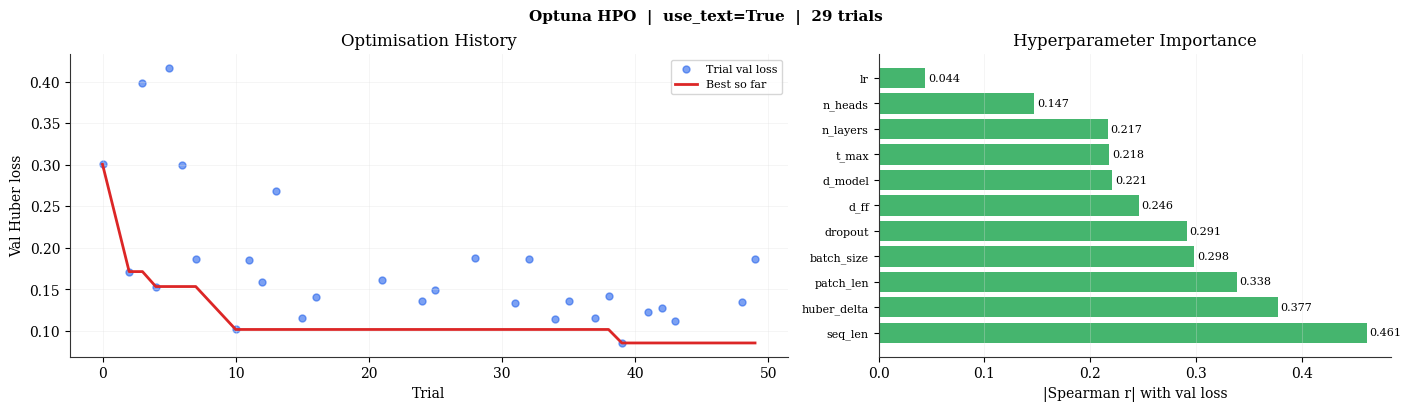

In [328]:
plot_optuna_results(study, CFG)

In [269]:
# ── 8.6  Retrain best config on full train+val, evaluate on test ─────────────
def retrain_best(
    study        : optuna.Study,
    splits       : dict,
    txt_dims     : Dict[str, int],
    cfg_base     : CCPLConfig,
    
) -> Tuple[CCPLTransformer, pd.DataFrame]:
    p = study.best_params

    best_cfg = CCPLConfig(
        data_path    = cfg_base.data_path,
        input_cols   = cfg_base.input_cols,
        target_col   = cfg_base.target_col,
        text_cols    = cfg_base.text_cols,
        text_encoder = cfg_base.text_encoder,
        tfidf_dim    = cfg_base.tfidf_dim,
        seq_len      = p["seq_len"],
        horizon      = cfg_base.horizon,
        patch_len    = p["patch_len"],
        d_model      = p["d_model"],
        d_ff         = p["d_ff"],
        n_heads      = p["n_heads"],
        n_layers     = p["n_layers"],
        dropout      = p["dropout"],
        batch_size   = p["batch_size"],
        n_epochs     = cfg_base.n_epochs,   # full training budget
        lr           = p["lr"],
        patience     = cfg_base.patience,
        huber_delta  = p["huber_delta"],
        t_max        = p["t_max"],
        out_dir      = os.path.join(cfg_base.out_dir, "optuna"),
    )

    isc = StandardScaler(); tsc = StandardScaler()
    (tl, vl, tel,
     tr_x, va_x, te_x,
     tr_y, va_y, te_y,
     _, _, _) = build_dataloaders(splits, isc, tsc, best_cfg)

    test_df = splits["test"]["df"]
    
    torch.manual_seed(0)
    best_m = build_model(best_cfg, txt_dims)
    tr_ls, va_ls = train_model(best_m, tl, vl, best_cfg,
                                ckpt_name="best_model.pt")

    preds_b, trues_b = predict(best_m, tel, tsc, best_cfg,
                                ckpt_name="best_model.pt")
    metrics_b = compute_metrics(preds_b, trues_b)

    print("\n=== BEST CONFIG TEST RESULTS ===")
    print_metrics_table(metrics_b, title="Best Optuna Config — Test Metrics")

    plot_loss_curves(tr_ls, va_ls, best_cfg, save_name="best_loss.png")
    plot_forecast_per_horizon(preds_b, trues_b, metrics_b, best_cfg,
                               save_name="best_forecast.png")
    plot_all_horizons(preds_b, trues_b, test_df,best_cfg,
                               save_name="best_forecast_allhorz.png", title_extra = "Energy")
     
    plot_horizon_metrics_bar(metrics_b, best_cfg, save_name="best_metrics.png")

    return best_m, metrics_b




Windows  (seq=12, H=4): train=244  val=41  test=41
  txt[fact] window shape: (244, 12, 384)
  txt[preds] window shape: (244, 12, 384)
Training  (epochs=200  patience=40)
 Epoch       Train         Val     BestVal    Time
--------------------------------------------------
     1    0.164999    0.189318    0.189318      1s
    20    0.105396    0.169600    0.085592     16s
    40    0.084093    0.201173    0.085592     35s
Early stop at epoch 55

Best val loss = 0.085592  saved -> outputs/ccpl/social2\optuna\best_model.pt

=== BEST CONFIG TEST RESULTS ===
  Best Optuna Config — Test Metrics
             MSE      MAE     RMSE    sMAPE%
Horizon                                     
h+1      0.03318  0.13363  0.18216   5.78658
h+2      0.07453  0.20637  0.27300   9.24948
h+3      0.09813  0.25967  0.31325  11.55725
h+4      0.12085  0.29582  0.34763  13.41698
Overall  0.08167  0.22387  0.28578  10.00257
Saved: outputs/ccpl/social2\optuna\best_loss.png


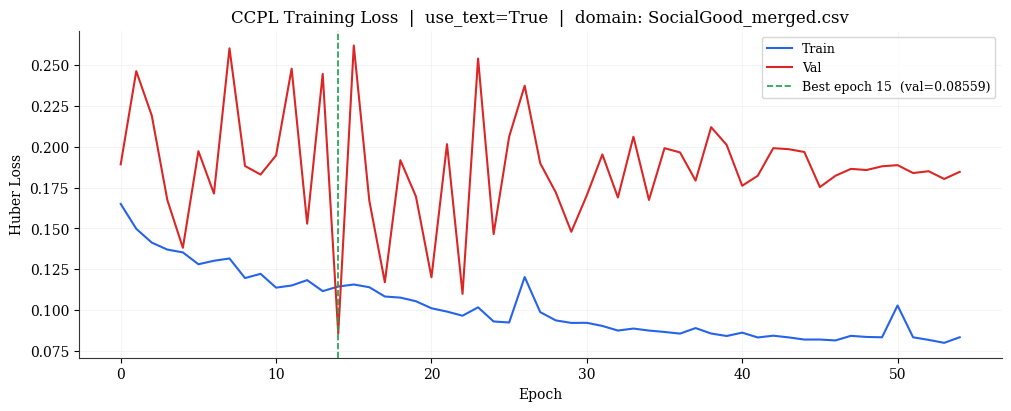

Saved: outputs/ccpl/social2\optuna\best_forecast.png


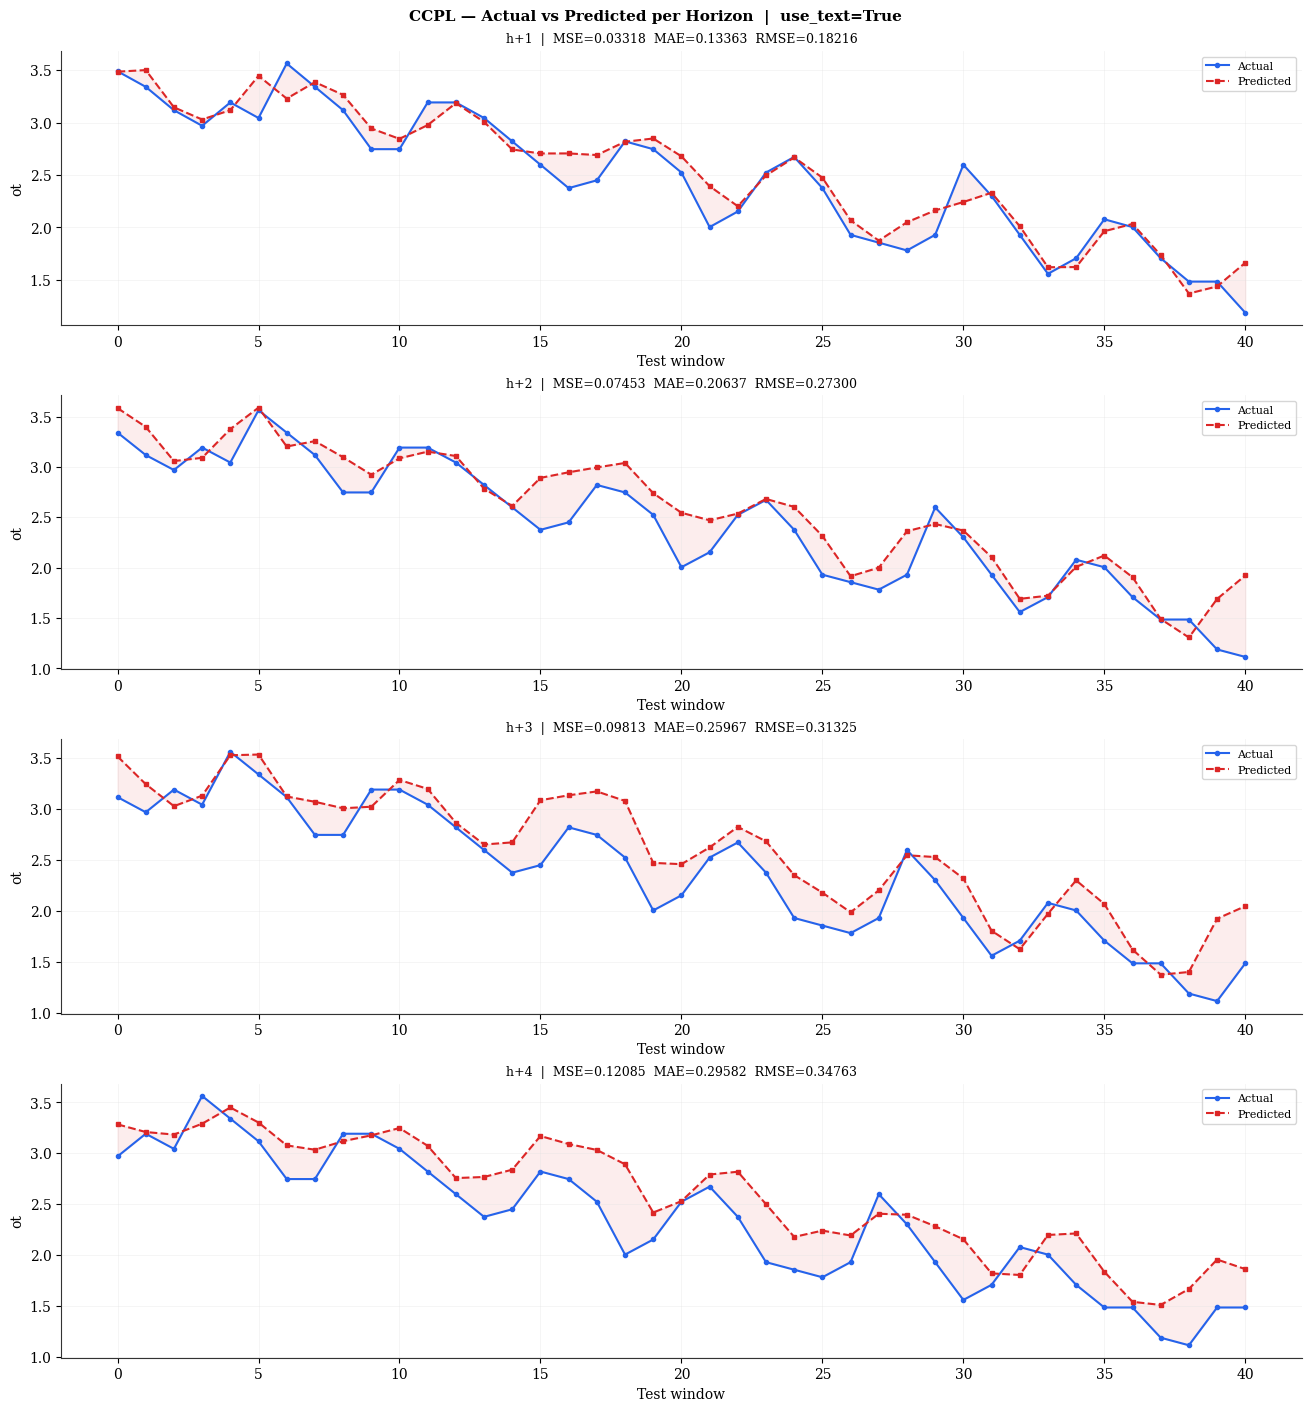

Saved -> outputs/ccpl/social2\optuna\best_forecast_allhorz.png


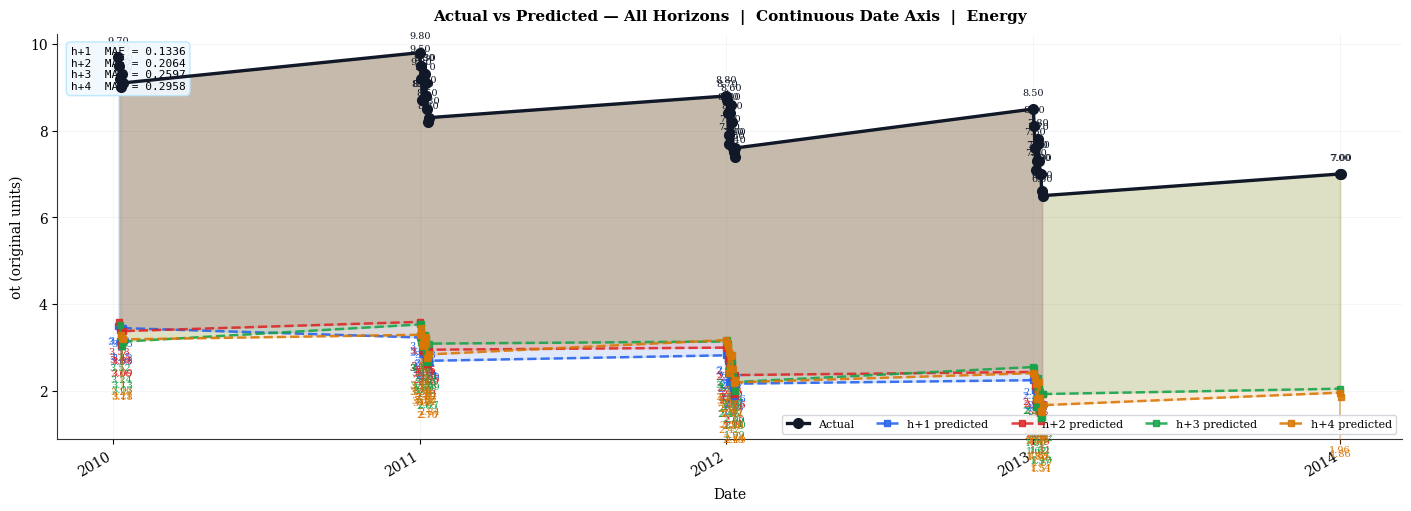

Saved: outputs/ccpl/social2\optuna\best_metrics.png


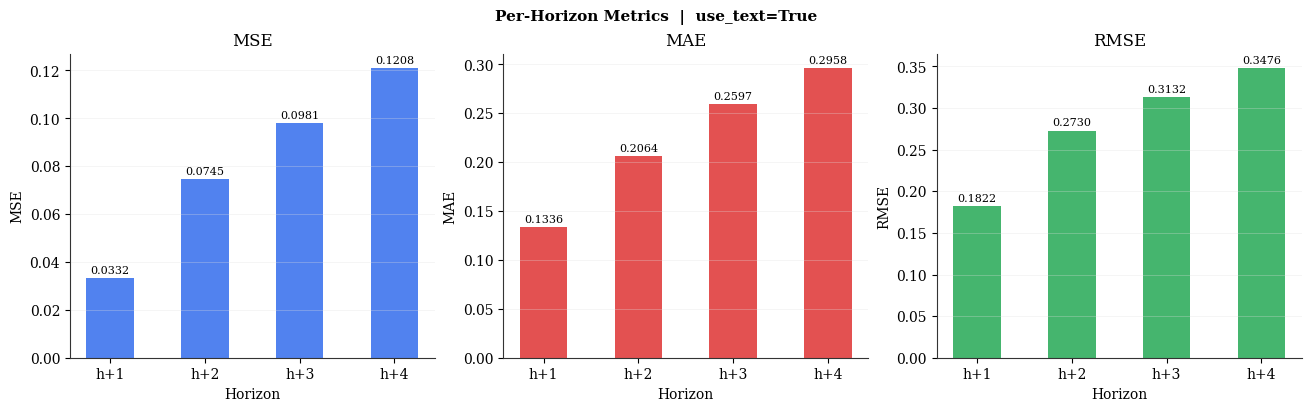

In [329]:
best_model_hpo, metrics_best = retrain_best(
    study, splits, TXT_DIMS, CFG)


## Diagnostic test data plot

Saved -> outputs/ccpl/test_data_diagnostic.png


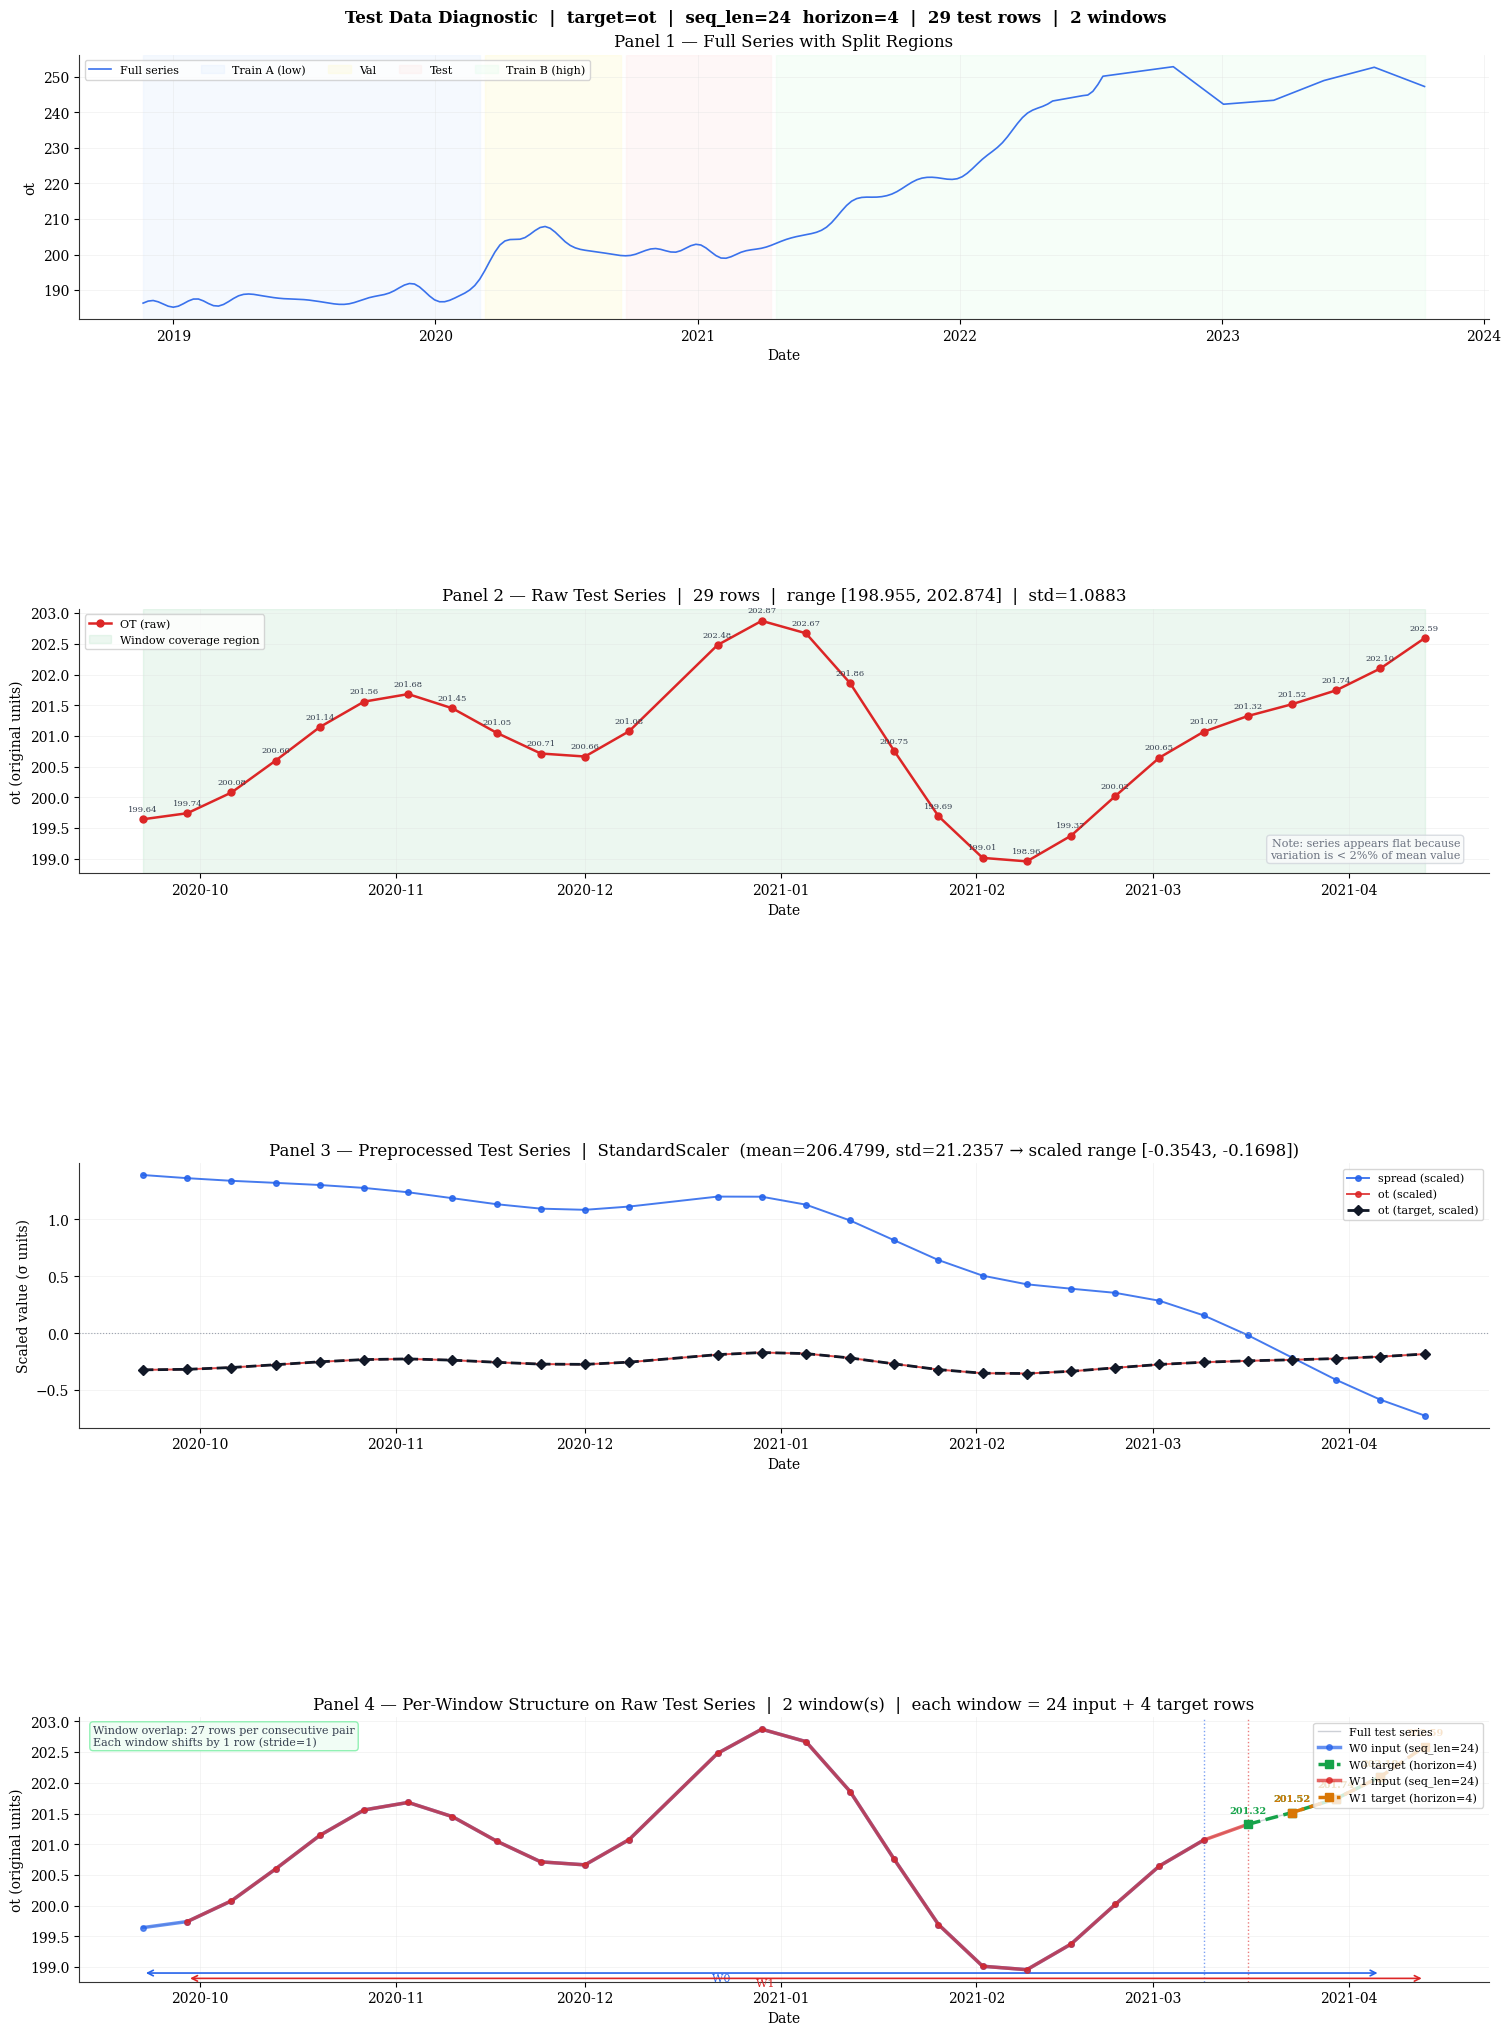

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.edgecolor"   : "#333333",
    "font.family"      : "serif",
    "grid.color"       : "#e0e0e0",
    "grid.linewidth"   : 0.6,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})
PALETTE = ["#2563EB", "#DC2626", "#16A34A", "#D97706",
           "#7C3AED", "#0891B2", "#BE185D"]


# ════════════════════════════════════════════════════════════════════════════════
# plot_test_data
# ════════════════════════════════════════════════════════════════════════════════
def plot_test_data(
    df            : pd.DataFrame,       # full dataset, date-indexed
    target_col    : str,                # e.g. "ot"
    input_scaler,                       # fitted StandardScaler for input features
    target_scaler,                      # fitted StandardScaler for target
    input_cols    : list,               # e.g. ["wholesale", "ot"]
    seq_len       : int,                # look-back window length
    horizon       : int,                # forecast horizon
    split_ratios  : tuple = (0.35, 0.65),  # (train_end_frac, mid_end_frac)
    out_path      : str   = None,       # save path, e.g. "outputs/test_data.png"
) -> None:
    """
    Four-panel diagnostic plot for the test split:

    Panel 1 — Raw full series with split regions highlighted
    Panel 2 — Raw test series (all rows, original units)
    Panel 3 — Preprocessed (scaled) test series
    Panel 4 — Per-window view: each sliding window's input (seq_len)
               and target (horizon) region drawn on the raw test series,
               with annotated window boundaries
    """

    # ── Compute split indices ─────────────────────────────────────────────────
    n         = len(df)
    train_end = int(n * split_ratios[0])
    mid_end   = int(n * split_ratios[1])
    val_end   = train_end + (mid_end - train_end) // 2
    test_idx  = list(range(val_end, mid_end))

    test_df  = df.iloc[test_idx].copy()
    dates    = test_df.index

    # ── Scaled test arrays ────────────────────────────────────────────────────
    te_raw_x  = test_df[input_cols].values.astype(np.float32)
    te_raw_y  = test_df[[target_col]].values.astype(np.float32)
    te_sc_x   = input_scaler.transform(te_raw_x)     # (T, n_vars)
    te_sc_y   = target_scaler.transform(te_raw_y)    # (T, 1)

    # ── Sliding window metadata ───────────────────────────────────────────────
    T       = len(test_df)
    N_win   = T - seq_len - horizon + 1
    windows = []
    for i in range(max(N_win, 0)):
        windows.append({
            "input_start" : i,
            "input_end"   : i + seq_len,          # exclusive
            "target_start": i + seq_len,
            "target_end"  : i + seq_len + horizon, # exclusive
            "input_dates" : dates[i : i + seq_len],
            "target_dates": dates[i + seq_len : i + seq_len + horizon],
            "input_raw"   : test_df[target_col].values[i : i + seq_len],
            "target_raw"  : test_df[target_col].values[i + seq_len : i + seq_len + horizon],
            "input_sc"    : te_sc_y[i : i + seq_len, 0],
            "target_sc"   : te_sc_y[i + seq_len : i + seq_len + horizon, 0],
        })

    # ── Figure layout ─────────────────────────────────────────────────────────
    n_panels = 4
    fig = plt.figure(figsize=(15, 5 * n_panels), constrained_layout=True)
    gs  = gridspec.GridSpec(n_panels, 1, figure=fig, hspace=0.45)
    axes = [fig.add_subplot(gs[i]) for i in range(n_panels)]

    fig.suptitle(
        "Test Data Diagnostic  |  target=%s  |  seq_len=%d  horizon=%d  |  %d test rows  |  %d windows"
        % (target_col, seq_len, horizon, T, len(windows)),
        fontsize=12, fontweight="bold", y=1.01,
    )

    # ─────────────────────────────────────────────────────────────────────────
    # Panel 1 — Full series with split regions
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(df.index, df[target_col], color=PALETTE[0],
            linewidth=1.2, alpha=0.9, label="Full series")

    region_cfg = [
        (0,         train_end, "#DBEAFE", "Train A (low)"),
        (train_end, val_end,   "#FEF9C3", "Val"),
        (val_end,   mid_end,   "#FEE2E2", "Test"),
        (mid_end,   n,         "#DCFCE7", "Train B (high)"),
    ]
    for s, e, color, label in region_cfg:
        ax.axvspan(df.index[s], df.index[e-1], alpha=0.25,
                   color=color, label=label)

    ax.set_title("Panel 1 — Full Series with Split Regions")
    ax.set_xlabel("Date"); ax.set_ylabel(target_col)
    ax.legend(fontsize=8, ncol=5, loc="upper left")
    ax.grid(True, alpha=0.4)

    # ─────────────────────────────────────────────────────────────────────────
    # Panel 2 — Raw test series
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[1]
    ax.plot(dates, test_df[target_col], color=PALETTE[1],
            linewidth=1.8, marker="o", markersize=5, label="OT (raw)")

    # Annotate actual values
    for d, v in zip(dates, test_df[target_col]):
        ax.annotate("%.2f" % v, xy=(d, v),
                    xytext=(0, 6), textcoords="offset points",
                    fontsize=6, ha="center", color="#374151")

    # Shade the window coverage region
    if windows:
        first_w = windows[0]
        last_w  = windows[-1]
        ax.axvspan(first_w["input_dates"][0], last_w["target_dates"][-1],
                   alpha=0.08, color=PALETTE[2],
                   label="Window coverage region")

    ax.set_title(
        "Panel 2 — Raw Test Series  |  %d rows  |  range [%.3f, %.3f]  |  std=%.4f"
        % (T, test_df[target_col].min(), test_df[target_col].max(),
           test_df[target_col].std())
    )
    ax.set_xlabel("Date"); ax.set_ylabel("%s (original units)" % target_col)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

    # Add text note explaining the flat appearance
    ax.text(0.98, 0.05,
            "Note: series appears flat because\nvariation is < 2%% of mean value",
            transform=ax.transAxes, fontsize=8,
            ha="right", va="bottom", color="#6B7280",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#F9FAFB",
                      edgecolor="#D1D5DB", alpha=0.8))

    # ─────────────────────────────────────────────────────────────────────────
    # Panel 3 — Preprocessed (scaled) test series
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[2]

    # Plot all scaled input features
    for j, col in enumerate(input_cols):
        col_idx = input_cols.index(col)
        ax.plot(dates, te_sc_x[:, col_idx],
                color=PALETTE[j % len(PALETTE)],
                linewidth=1.4, marker="o", markersize=4,
                alpha=0.85, label=col + " (scaled)")

    # Highlight the scaled target separately with markers
    ax.plot(dates, te_sc_y[:, 0],
            color="#111827", linewidth=2, linestyle="--",
            marker="D", markersize=5, label=target_col + " (target, scaled)",
            zorder=5)

    ax.axhline(0, color="#9CA3AF", linewidth=0.8, linestyle=":")
    ax.set_title(
        "Panel 3 — Preprocessed Test Series  |  StandardScaler  "
        "(mean=%.4f, std=%.4f → scaled range [%.4f, %.4f])"
        % (target_scaler.mean_[0][0], target_scaler.std_[0][0],
           te_sc_y.min(), te_sc_y.max())
    )
    ax.set_xlabel("Date"); ax.set_ylabel("Scaled value (σ units)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

    # ─────────────────────────────────────────────────────────────────────────
    # Panel 4 — Per-window structure on raw test series
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[3]

    # Background: full raw test series in light grey
    ax.plot(dates, test_df[target_col], color="#9CA3AF",
            linewidth=1, alpha=0.5, zorder=1, label="Full test series")

    if not windows:
        ax.text(0.5, 0.5,
                "No complete windows available.\n"
                "Need at least seq_len + horizon = %d rows,\n"
                "but test split has only %d rows.\n\n"
                "Reduce seq_len or increase dataset size."
                % (seq_len + horizon, T),
                transform=ax.transAxes, ha="center", va="center",
                fontsize=10, color="#DC2626",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="#FEF2F2",
                          edgecolor="#FCA5A5"))
    else:
        for wi, w in enumerate(windows):
            c_in  = PALETTE[wi % len(PALETTE)]
            c_tar = PALETTE[(wi + 2) % len(PALETTE)]

            # Input region — solid line
            ax.plot(w["input_dates"], w["input_raw"],
                    color=c_in, linewidth=2.5, alpha=0.7,
                    marker="o", markersize=4, zorder=3,
                    label="W%d input (seq_len=%d)" % (wi, seq_len))

            # Target region — dashed line
            ax.plot(w["target_dates"], w["target_raw"],
                    color=c_tar, linewidth=2.5, linestyle="--",
                    marker="s", markersize=6, zorder=4,
                    label="W%d target (horizon=%d)" % (wi, horizon))

            # Vertical divider between input and target
            divider = w["input_dates"][-1]
            ax.axvline(divider, color=c_in, linewidth=1,
                       linestyle=":", alpha=0.6)

            # Annotate target values
            for d, v in zip(w["target_dates"], w["target_raw"]):
                ax.annotate("%.2f" % v, xy=(d, v),
                            xytext=(0, 8), textcoords="offset points",
                            fontsize=7, ha="center", color=c_tar,
                            fontweight="bold")

            # Window bracket annotation
            y_bracket = (test_df[target_col].min()
                         - 0.05 * test_df[target_col].std()
                         - wi * 0.08 * test_df[target_col].std())
            ax.annotate(
                "", xy=(w["target_dates"][-1], y_bracket),
                xytext=(w["input_dates"][0], y_bracket),
                arrowprops=dict(arrowstyle="<->", color=c_in,
                                lw=1.2, connectionstyle="arc3,rad=0"),
            )
            ax.text(
                w["input_dates"][len(w["input_dates"])//2], y_bracket,
                "  W%d" % wi, fontsize=8, color=c_in,
                va="top", ha="center",
            )

        # Overlap info box
        if len(windows) > 1:
            overlap = seq_len + horizon - 1   # rows shared between consecutive windows
            ax.text(
                0.01, 0.97,
                "Window overlap: %d rows per consecutive pair\n"
                "Each window shifts by 1 row (stride=1)"
                % overlap,
                transform=ax.transAxes, fontsize=8,
                va="top", color="#374151",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#F0FDF4",
                          edgecolor="#86EFAC", alpha=0.9),
            )

    ax.set_title(
        "Panel 4 — Per-Window Structure on Raw Test Series  |  "
        "%d window(s)  |  each window = %d input + %d target rows"
        % (len(windows), seq_len, horizon)
    )
    ax.set_xlabel("Date"); ax.set_ylabel("%s (original units)" % target_col)
    ax.legend(fontsize=8, loc="upper right"); ax.grid(True, alpha=0.4)

    # ── Save / show ───────────────────────────────────────────────────────────
    if out_path:
        import os
        os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        print("Saved ->", out_path)
    plt.show()


# ════════════════════════════════════════════════════════════════════════════════
# Usage — paste after Section 3 in CCPL_pipeline.ipynb
# ════════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    # Assumes these objects exist from running Sections 1–3 of CCPL_pipeline.ipynb:
    #   df, CFG, input_scaler, target_scaler
    plot_test_data(
        df            = df,
        target_col    = CFG.target_col,
        input_scaler  = input_scaler,
        target_scaler = target_scaler,
        input_cols    = CFG.input_cols,
        seq_len       = CFG.seq_len,
        horizon       = CFG.horizon,
        split_ratios  = (0.35, 0.65),
        out_path      = "outputs/ccpl/test_data_diagnostic.png",
    )